## 1. Initialisation

### 1.1 Importations des Librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # Pour les expressions régulières (utiles pour CYTOGENETICS)
import os

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Options d'affichage pour pandas et matplotlib/seaborn
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x) # Afficher les floats avec 3 décimales
# plt.style.use('seaborn-v0_8-whitegrid') # Utilisation d'un style seaborn
%matplotlib inline

import warnings
warnings.filterwarnings('ignore') # Ignorer les warnings pour la clarté

### 1.2 Fonctions Utilitaires

Nous définissons ici plusieurs fonctions qui nous aideront à prétraiter et à créer de nouvelles variables.

In [2]:
def parse_cytogenetics(ct_str):
    if pd.isna(ct_str):
        base = dict.fromkeys([
            'sex','ploidy_median',
            'monosomy_count','trisomy_count','deletion_count','addition_count',
            'translocation_count','derivative_count','dicentric_count',
            'insertion_count','inversion_count',
            'complex_karyotype','normal_karyotype'
        ], np.nan)
        base.update({'is_adverse_cyto': False})
        return base

    s = ct_str.lower().replace(' ', '')
    parts = s.split(',')

    sex = np.nan
    if len(parts) > 1:
        m = re.match(r'^(xx|xy)', parts[1])
        if m:
            sex = 0 if m.group(1) == 'xx' else 1

    m = re.match(r'(\d+)(?:[-~](\d+))?', parts[0])
    if m:
        pmin = int(m.group(1))
        pmax = int(m.group(2)) if m.group(2) else pmin
        pmed = (pmin + pmax) / 2
    else:
        pmed = np.nan

    monosomy     = len(re.findall(r'-(?:[0-9]+|x|y)(?!\()', s))
    trisomy      = len(re.findall(r'\+(?:[0-9]+|x|y)(?!\()', s))
    deletions    = len(re.findall(r'del\(', s))
    additions    = len(re.findall(r'add\(', s))
    translocs    = len(re.findall(r't\(', s))
    derivatives  = len(re.findall(r'der\(', s))
    dicentrics   = len(re.findall(r'dic\(', s))
    insertions   = len(re.findall(r'ins\(', s))
    inversions   = len(re.findall(r'inv\(', s))

    complex_flag = 1 if re.search(r'complex|multiple', s) else 0
    normal_flag  = 1 if (monosomy + trisomy + deletions + additions +
                        translocs + derivatives + dicentrics +
                        insertions + inversions) == 0 else 0

    adv_patterns = [
        r'inv\(3\)', r't\(3;3\)', r't\(6;9\)', r't\(9;22\)', r't\(3q26\.2\)', r't\(8;16\)',
        r'-5(?!\()', r'del\(5q\)', r'-7(?!\()', r'del\(7q\)', r'complex'
    ]

    is_adv = bool(re.search('|'.join(adv_patterns), s)) or (monosomy >= 2)

    return {
        'sex': sex,
        'ploidy_median': pmed,
        'monosomy_count': monosomy,
        'trisomy_count': trisomy,
        'deletion_count': deletions,
        'addition_count': additions,
        'translocation_count': translocs,
        'derivative_count': derivatives,
        'dicentric_count': dicentrics,
        'insertion_count': insertions,
        'inversion_count': inversions,
        'complex_karyotype': complex_flag,
        'normal_karyotype': normal_flag,
        'is_adverse_cyto': is_adv
    }

def extract_cyto_features(df, col='CYTOGENETICS'):
    return df[col].apply(parse_cytogenetics).apply(pd.Series)


def encode_protein_change(protein):
    """
    Encode la colonne PROTEIN_CHANGE pour regrouper les mutations rares
    et conserver les mutations fréquentes ou d'intérêt.
    """
    if pd.isna(protein):
        return "missing" # Ou np.nan si on préfère gérer avec imputer plus tard

    frequent_mutations = ['p.K700E', 'p.G646fs*12', 'MLL_PTD', 'p.V617F'] # Exemple de mutations fréquentes
    if protein in frequent_mutations:
        return protein
    elif protein.startswith('p.P95'): # Exemple de regroupement
        return 'p.P95X'
    elif protein == 'p.?':
        return 'unknown'
    else:
        return 'rare'

def add_outlier_flags(df, col_list):
    """
    Ajoute des flags binaires pour les outliers (valeurs > 99ème percentile ou < 1er percentile)
    pour les colonnes spécifiées.
    """
    df_out = df.copy()
    for col in col_list:
        if col in df_out.columns and pd.api.types.is_numeric_dtype(df_out[col]):
            high_perc = df_out[col].quantile(0.99)
            low_perc = df_out[col].quantile(0.01)
            df_out[f'{col}_high_outlier'] = (df_out[col] > high_perc).astype(int)
            df_out[f'{col}_low_outlier'] = (df_out[col] < low_perc).astype(int)
    return df_out

def add_interaction_features(df):
    """
    Ajoute des features d'interaction. Exemple: ratio ANC/WBC.
    """
    df_out = df.copy()
    if 'ANC' in df_out.columns and 'WBC' in df_out.columns:
        # Ajout d'un petit epsilon pour éviter la division par zéro si WBC est 0 (ou proche après imputation)
        df_out['ANC_WBC_ratio'] = df_out['ANC'] / (df_out['WBC'] + 1e-6)
    return df_out

def add_missing_molecular_flag(clinical_df, molecular_df_ids_with_data):
    """
    Ajoute un flag indiquant si un patient a des données moléculaires.
    `molecular_df_ids_with_data` doit être une série ou un set des ID uniques présents dans les données moléculaires.
    """
    df_out = clinical_df.copy()
    df_out['has_molecular_data'] = df_out['ID'].isin(molecular_df_ids_with_data).astype(int)
    return df_out

def aggregate_molecular_data(mol_df):
    """
    Agrège les données moléculaires pour avoir une ligne par patient.
    Calcule des statistiques sur VAF, DEPTH, compte le nombre de mutations,
    et flag la présence de mutations dans des gènes importants.
    """
    if mol_df.empty:
        # Retourner un DataFrame vide avec les colonnes attendues si pas de données moléculaires
        cols = ["ID", "VAF_mean", "VAF_max", "VAF_min", "DEPTH_mean", "unique_genes_count", "mutation_count"]
        # Ajouter les gènes importants
        important_genes = ["NPM1", "FLT3", "DNMT3A", "TP53", "CEBPA", "TET2", "ASXL1", "SF3B1", "IDH1", "IDH2", "RUNX1"] # Exemple étendu
        for gene in important_genes:
            cols.append(f"has_mutation_in_{gene}")
        return pd.DataFrame(columns=cols)

    agg_funcs = {
        "VAF": ["mean", "max", "min"],
        "DEPTH": "mean",
        "GENE": ["nunique", "count"] # nunique pour gènes uniques, count pour nombre total de mutations
    }

    mol_agg = mol_df.groupby("ID").agg(agg_funcs).reset_index()
    mol_agg.columns = ["ID", "VAF_mean", "VAF_max", "VAF_min", "DEPTH_mean", "unique_genes_count", "mutation_count"]

    # Pivot pour encoder la présence d'une mutation dans certains gènes importants
    # Gènes importants (liste à adapter/confirmer selon le contexte du challenge)
    important_genes = ["NPM1", "FLT3", "DNMT3A", "TP53", "CEBPA", "TET2", "ASXL1", "SF3B1", "IDH1", "IDH2", "RUNX1"]

    # Pour chaque gène important, vérifier sa présence pour chaque patient
    for gene in important_genes:
        gene_presence = mol_df[mol_df["GENE"] == gene].groupby("ID").size().reset_index(name=f"has_mutation_in_{gene}")
        gene_presence[f"has_mutation_in_{gene}"] = 1 # Marquer la présence
        mol_agg = mol_agg.merge(gene_presence, on="ID", how="left")
        mol_agg[f"has_mutation_in_{gene}"].fillna(0, inplace=True) # Les patients sans mutation dans ce gène auront NaN -> 0
        mol_agg[f"has_mutation_in_{gene}"] = mol_agg[f"has_mutation_in_{gene}"].astype(int)

    return mol_agg

def process_gene_column(df, threshold=10): # Seuil ajusté par rapport à "Code Ultime" (50->10)
    """
    Traite la colonne GENE pour regrouper les gènes rarement mutés sous la catégorie "OTHER".
    Retourne le DataFrame modifié et la liste des gènes rares.
    """
    df_out = df.copy()
    if "GENE" not in df_out.columns:
        return df_out, []

    gene_counts = df_out["GENE"].value_counts()
    rare_genes = gene_counts[gene_counts < threshold].index
    df_out["GENE_processed"] = df_out["GENE"].replace(rare_genes, "OTHER")
    return df_out, list(rare_genes)

# Fonction pour visualiser les valeurs manquantes
def plot_missing_values(df, title=""):
    """Affiche un barplot du pourcentage de valeurs manquantes par colonne."""
    missing_percentage = df.isnull().mean() * 100
    missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

    if missing_percentage.empty:
        print(f"Aucune valeur manquante dans le DataFrame {title}.")
        return

    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_percentage.index, y=missing_percentage.values, palette="viridis")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Pourcentage de Valeurs Manquantes - {title}")
    plt.ylabel("Pourcentage (%)")
    plt.show()

def plot_numerical_distributions(df, columns, title_suffix=""):
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from scipy.stats import gaussian_kde

    for col in columns:
        if col not in df.columns:
            print(f"Colonne {col} absente du DataFrame.")
            continue

        # 1. Conversion en float + suppression des NaN
        series = pd.to_numeric(df[col], errors='coerce').dropna().astype(np.float32)
        if series.empty:
            print(f"Colonne {col} vide après nettoyage.")
            continue

        arr = series.values  # array 1D garanti

        # 2. Création de la figure
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # 2a. Histogramme normalisé
        axes[0].hist(arr, bins=30, density=True, alpha=0.6)
        axes[0].set_title(f'Distribution de {col} {title_suffix}')

        # 2b. KDE via SciPy
        try:
            kde = gaussian_kde(arr)
            x_grid = np.linspace(arr.min(), arr.max(), 200)
            axes[0].plot(x_grid, kde(x_grid), lw=2)
        except Exception as e:
            print(f"Impossible de tracer la KDE pour {col} : {e}")

        # 2c. Boxplot (horizontal)
        axes[1].boxplot(arr, vert=False)
        axes[1].set_title(f'Boxplot de {col} {title_suffix}')

        plt.tight_layout()
        plt.show()

# Fonction pour afficher les distributions des variables catégorielles
def plot_categorical_distributions(df, columns, title_suffix=""):
    """Affiche des countplots pour les colonnes catégorielles spécifiées."""
    for col in columns:
        if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
            plt.figure(figsize=(10, 5))
            sns.countplot(y=df[col], order=df[col].value_counts().index[:20], palette="viridis") # Top 20 modalités
            plt.title(f'Distribution de {col} {title_suffix}')
            plt.xlabel('Nombre d\'occurrences')
            plt.ylabel(col)
            plt.tight_layout()
            plt.show()
        else:
            print(f"Colonne {col} non trouvée ou non catégorielle.")

# 2. Chargement des Données

Les données sont stockées dans le dossier `0_data/`. Nous chargeons les trois fichiers principaux : `clinical_train.csv`, `molecular_train.csv`, et `target_train.csv`.

In [3]:
# 1. Monter Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Définir les chemins absolus
base_path = "/content/drive/MyDrive/QRT"
path_clinical_train = f"{base_path}/0_data/clinical_train.csv"
path_molecular_train = f"{base_path}/0_data/molecular_train.csv"
path_target_train = f"{base_path}/0_data/target_train.csv"

def safe_read_csv(path):
    if os.path.exists(path):
        print(f"Chargement de : {path}")
        return pd.read_csv(path, index_col=False)
    else:
        print(f"Fichier introuvable : {path}")
        return None

df_clinical = safe_read_csv(path_clinical_train)
df_molecular = safe_read_csv(path_molecular_train)
df_target = safe_read_csv(path_target_train)

# Affichage des dimensions et des premières lignes
print("Données Cliniques (df_clinical):")
print("Dimensions:", df_clinical.shape)
display(df_clinical.head())
print("\n" + "="*50 + "\n")

print("Données Moléculaires (df_molecular):")
print("Dimensions:", df_molecular.shape)
display(df_molecular.head())
print("\n" + "="*50 + "\n")

print("Données Cible (df_target):")
print("Dimensions:", df_target.shape)
display(df_target.head())

Mounted at /content/drive
Chargement de : /content/drive/MyDrive/QRT/0_data/clinical_train.csv
Chargement de : /content/drive/MyDrive/QRT/0_data/molecular_train.csv
Chargement de : /content/drive/MyDrive/QRT/0_data/target_train.csv
Données Cliniques (df_clinical):
Dimensions: (3323, 9)


,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.000,2.800,0.200,0.700,7.600,119.000,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.000,7.400,2.400,0.100,11.600,42.000,"46,xx"
2,P116889,MSK,15.000,3.700,2.100,0.100,14.200,81.000,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.000,3.900,1.900,0.100,8.900,77.000,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.000,128.000,9.700,0.900,11.100,195.000,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"




Données Moléculaires (df_molecular):
Dimensions: (10935, 11)


,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
0,P100000,11,119149248.000,119149248.000,G,A,CBL,p.C419Y,non_synonymous_codon,0.083,1308.000
1,P100000,5,131822301.000,131822301.000,G,T,IRF1,p.Y164*,stop_gained,0.022,532.000
2,P100000,3,77694060.000,77694060.000,G,C,ROBO2,p.?,splice_site_variant,0.410,876.000
3,P100000,4,106164917.000,106164917.000,G,T,TET2,p.R1262L,non_synonymous_codon,0.430,826.000
4,P100000,2,25468147.000,25468163.000,ACGAAGAGGGGGTGTTC,A,DNMT3A,p.E505fs*141,frameshift_variant,0.090,942.000




Données Cible (df_target):
Dimensions: (3323, 3)


,ID,OS_YEARS,OS_STATUS
0,P132697,1.115,1.000
1,P132698,4.929,0.000
2,P116889,2.044,0.000
3,P132699,2.477,1.000
4,P132700,3.145,0.000


## 3. Analyse de la Cible (target_train)

La cible de notre prédiction est liée à la survie du patient. Examinons les variables `OS_STATUS` (statut de survie, probablement 0 = vivant, 1 = décédé) et `OS_YEARS` (durée de survie en années).

In [4]:
# Fusionner la cible avec les données cliniques pour une première analyse conjointe
df_train = df_clinical.merge(df_target, on="ID", how="left") # how="left" pour garder tous les patients cliniques

print("Informations sur df_train (après fusion avec la cible):")
df_train.info()

print("\nValeurs manquantes pour les colonnes cibles dans df_train:")
print(df_train[['OS_STATUS', 'OS_YEARS']].isnull().sum())

Informations sur df_train (après fusion avec la cible):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3323 entries, 0 to 3322
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            3323 non-null   object 
 1   CENTER        3323 non-null   object 
 2   BM_BLAST      3214 non-null   float64
 3   WBC           3051 non-null   float64
 4   ANC           3130 non-null   float64
 5   MONOCYTES     2722 non-null   float64
 6   HB            3213 non-null   float64
 7   PLT           3199 non-null   float64
 8   CYTOGENETICS  2936 non-null   object 
 9   OS_YEARS      3173 non-null   float64
 10  OS_STATUS     3173 non-null   float64
dtypes: float64(8), object(3)
memory usage: 285.7+ KB

Valeurs manquantes pour les colonnes cibles dans df_train:
OS_STATUS    150
OS_YEARS     150
dtype: int64


### 3.1 OS_STATUS

`OS_STATUS` est notre variable cible principale pour la classification du risque de décès.


Description de OS_STATUS:
OS_STATUS
1.000    1600
0.000    1573
NaN       150
Name: count, dtype: int64


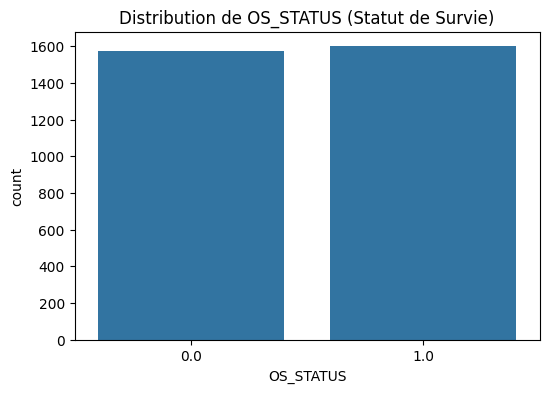


Dimensions de df_train après suppression des OS_STATUS manquants: (3173, 11)
Nouvelle distribution de OS_STATUS après nettoyage:
OS_STATUS
1    1600
0    1573
Name: count, dtype: int64


In [5]:
# EDA de OS_STATUS
print("\nDescription de OS_STATUS:")
print(df_train['OS_STATUS'].value_counts(dropna=False)) # Inclure les NaNs s'il y en a

plt.figure(figsize=(6,4))
sns.countplot(x='OS_STATUS', data=df_train.dropna(subset=['OS_STATUS'])) # Exclure les NaNs pour le plot
plt.title('Distribution de OS_STATUS (Statut de Survie)')
plt.show()

# Prétraitement de OS_STATUS
# Justification: La variable cible doit être numérique et ne pas contenir de valeurs manquantes
# pour la plupart des modèles de classification.
# Les lignes avec OS_STATUS manquantes ne peuvent pas être utilisées pour l'entraînement supervisé.
df_train.dropna(subset=['OS_STATUS'], inplace=True)
df_train['OS_STATUS'] = pd.to_numeric(df_train['OS_STATUS'], errors='coerce').astype(int) # Assurer le type entier

print(f"\nDimensions de df_train après suppression des OS_STATUS manquants: {df_train.shape}")
print(f"Nouvelle distribution de OS_STATUS après nettoyage:\n{df_train['OS_STATUS'].value_counts()}")

### 3.2 OS_YEARS

`OS_YEARS` donne la durée de survie. Cette variable est utile pour l'analyse de survie mais sera probablement retirée pour une classification binaire simple basée sur `OS_STATUS`.

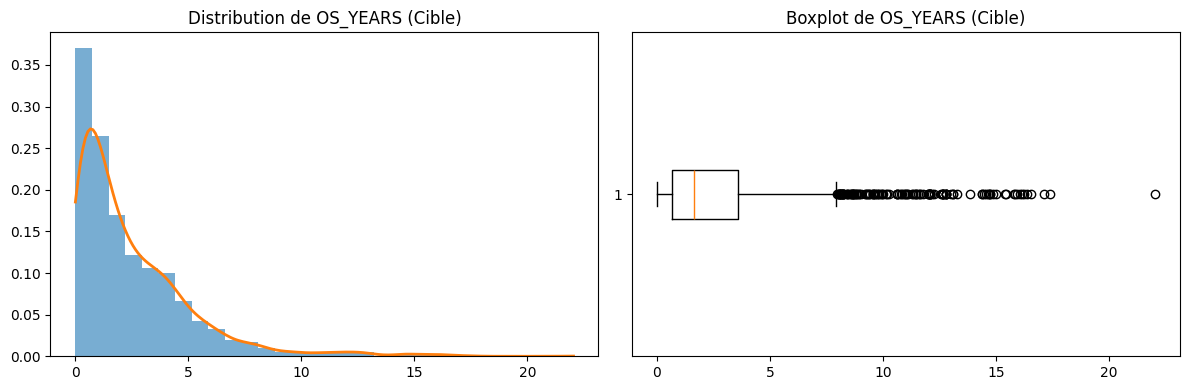


Description de OS_YEARS:
count   3173.000
mean       2.481
std        2.588
min        0.000
25%        0.652
50%        1.652
75%        3.573
max       22.044
Name: OS_YEARS, dtype: float64


In [6]:
# EDA de OS_YEARS
plot_numerical_distributions(df_train, ['OS_YEARS'], title_suffix="(Cible)")

print("\nDescription de OS_YEARS:")
print(df_train['OS_YEARS'].describe())

# Justification: Pour ce notebook axé sur la préparation des données pour une classification binaire
# (prédire OS_STATUS), OS_YEARS ne sera pas directement utilisé comme feature ou cible transformée.
# Elle est conservée pour l'instant mais sera exclue du jeu de features X.

## 4. Analyse Exploratoire et Prétraitement des Données Cliniques (df_clinical)

Nous allons maintenant explorer `df_clinical` (qui est maintenant la base de `df_train` après la fusion et le nettoyage de la cible).
Les colonnes présentes initialement dans `df_clinical` sont: `ID`, `CENTER`, `BM_BLAST`, `WBC`, `ANC`, `MONOCYTES`, `HB`, `PLT`, `CYTOGENETICS`.
`ID` a déjà servi pour la fusion. `OS_STATUS` et `OS_YEARS` viennent de `df_target`.

Informations générales sur les données cliniques (dans df_train):
<class 'pandas.core.frame.DataFrame'>
Index: 3173 entries, 0 to 3322
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CENTER        3173 non-null   object 
 1   BM_BLAST      3094 non-null   float64
 2   WBC           2944 non-null   float64
 3   ANC           3032 non-null   float64
 4   MONOCYTES     2629 non-null   float64
 5   HB            3098 non-null   float64
 6   PLT           3087 non-null   float64
 7   CYTOGENETICS  2825 non-null   object 
dtypes: float64(6), object(2)
memory usage: 223.1+ KB
None

Statistiques descriptives pour les features numériques cliniques:


,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT
count,3094.000,2944.000,3032.000,2629.000,3098.000,3087.000
mean,6.071,6.597,3.286,0.972,9.862,167.071
std,7.663,10.406,5.308,2.711,2.031,150.234
min,0.000,0.200,0.000,0.000,4.000,2.000
25%,1.000,2.700,1.000,0.149,8.500,65.000
50%,3.000,4.100,2.000,0.370,9.700,123.000
75%,8.000,6.700,3.700,0.792,11.100,229.500
max,91.000,154.400,109.620,44.200,16.600,1451.000



Modalités pour les features catégorielles cliniques:


,CENTER,CYTOGENETICS
count,3173,2825
unique,23,1171
top,KI,"46,xy[20]"
freq,820,426


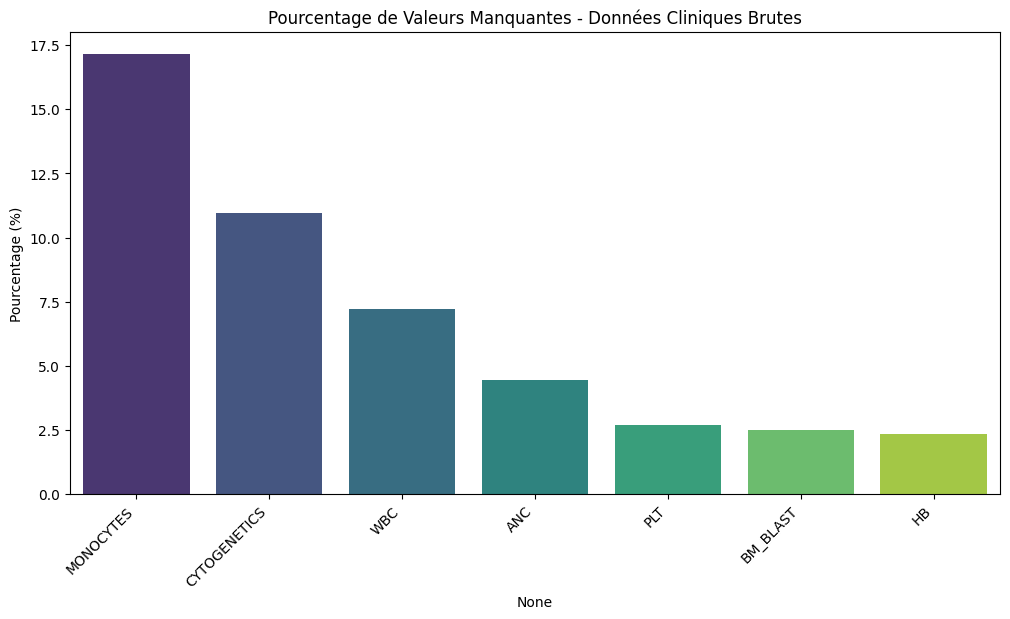

In [7]:
print("Informations générales sur les données cliniques (dans df_train):")
# Exclure les colonnes cibles pour se concentrer sur les features cliniques originales
clinical_features_original = ['CENTER', 'BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT', 'CYTOGENETICS']
print(df_train[clinical_features_original].info())

print("\nStatistiques descriptives pour les features numériques cliniques:")
display(df_train[clinical_features_original].describe(include=np.number))

print("\nModalités pour les features catégorielles cliniques:")
display(df_train[clinical_features_original].describe(include='object'))

plot_missing_values(df_train[clinical_features_original], title="Données Cliniques Brutes")

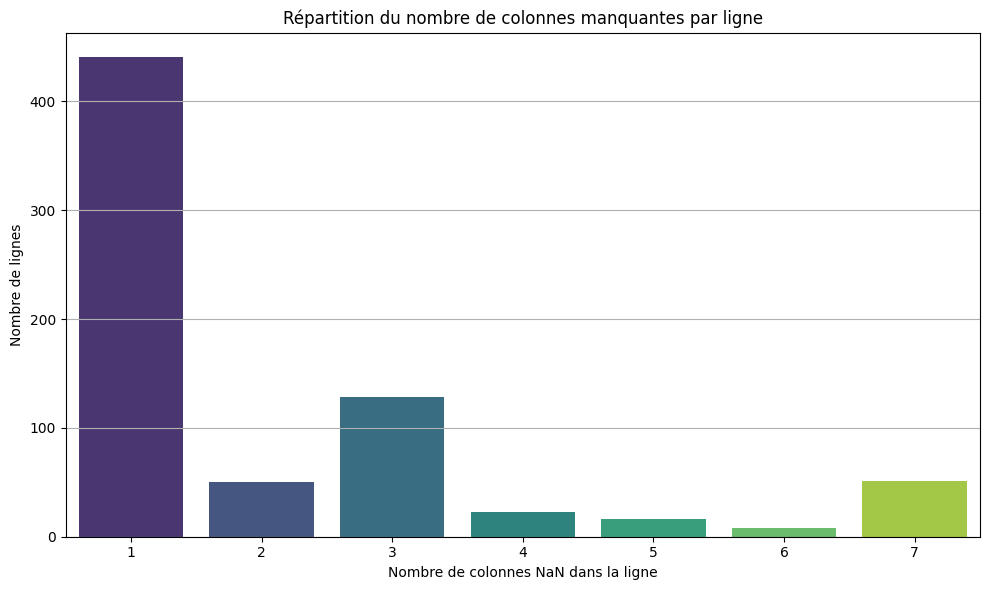

In [8]:
# Nombre de NaNs par ligne
nan_per_row = df_train.isnull().sum(axis=1)

# Filtrer uniquement les lignes avec au moins un NaN
nan_counts = nan_per_row[nan_per_row > 0]

# Compter la fréquence de chaque nombre de colonnes NaN
nan_distribution = nan_counts.value_counts().sort_index().reset_index()
nan_distribution.columns = ['Nombre_de_colonnes_NaN', 'Nombre_de_lignes']

# Tracer avec seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    data=nan_distribution,
    x='Nombre_de_colonnes_NaN',
    y='Nombre_de_lignes',
    palette='viridis'
)
plt.xlabel("Nombre de colonnes NaN dans la ligne")
plt.ylabel("Nombre de lignes")
plt.title("Répartition du nombre de colonnes manquantes par ligne")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [9]:
# Nombre de NaNs par ligne
nan_per_row = df_train.isnull().sum(axis=1)

# Lignes avec exactement 1 ou 2 NaNs
rows_with_one_nan = df_train[nan_per_row == 1]
rows_with_two_nan = df_train[nan_per_row == 2]

# Pour chaque ligne avec 1 NaN, récupérer la colonne concernée
missing_column_in_one_nan_rows = rows_with_one_nan.apply(lambda row: row[row.isna()].index[0], axis=1)
missing_counts_1 = missing_column_in_one_nan_rows.value_counts()

# Pour chaque ligne avec 2 NaNs, récupérer la paire triée des colonnes manquantes
missing_columns_in_two_nan_rows = rows_with_two_nan.apply(
    lambda row: tuple(sorted(row[row.isna()].index)), axis=1
)
missing_counts_2 = missing_columns_in_two_nan_rows.value_counts()

# Affichage
print("Colonnes seules manquantes (1 NaN) :")
print(missing_counts_1)

Colonnes seules manquantes (1 NaN) :
MONOCYTES       282
CYTOGENETICS    125
BM_BLAST         20
ANC              10
PLT               2
WBC               2
Name: count, dtype: int64


**Important de traiter les missing values de MONOCYTES**

**CYTOGENETICS étant sous une forme de regex: 46,xy,t(3;3)(q25;q27)[8]/46,xy[12].**

**Il est trop complexe de vouloir remplacer les missing values. On va supprimer les lignes comprenant des missing_values pour CYTOGENETICS.**

### 4.1 CENTER

**Description:** Centre hospitalier où le patient a été traité.
**Type:** Catégoriel.
**Observation:**

CENTER
KI       820
DUS      445
PV       316
GESMD    245
RMCN     199
CCH      140
CGM      107
ROM      103
UOB       87
MUV       83
FUCE      73
TUD       73
ICO       71
FLO       68
DUTH      66
HMS       51
UOXF      48
HIAE      47
MSK       37
IHBT      33
VU        29
UMG       26
REL        6
Name: count, dtype: int64


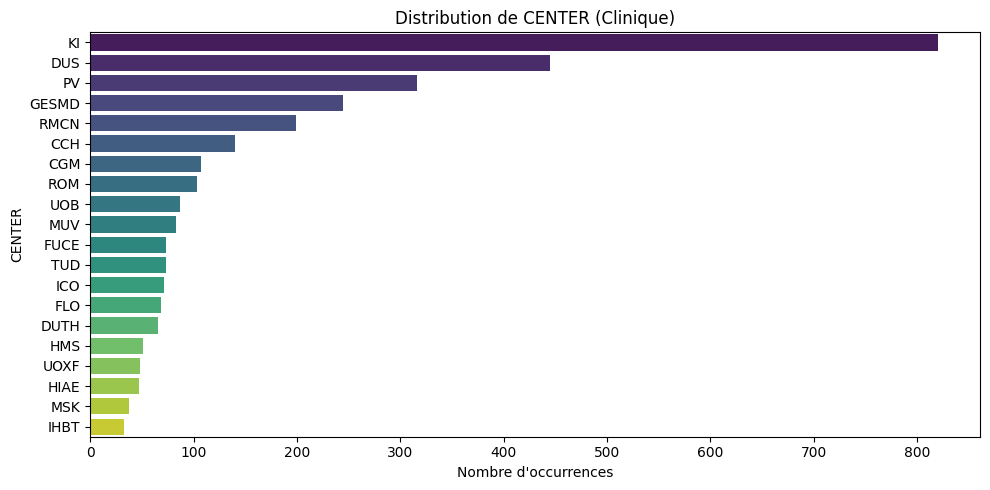

In [10]:
print(df_train['CENTER'].value_counts(dropna=False))
plot_categorical_distributions(df_train, ['CENTER'], title_suffix="(Clinique)")

**Prétraitement et Justification:**
* **Valeurs manquantes:** Si présentes, elles pourraient être imputées par la modalité la plus fréquente ou une catégorie 'Missing'. Ici, il semble qu'il n'y en ait pas.
* **Encodage:** Cette variable est catégorielle. Un encodage One-Hot est approprié car il n'y a pas d'ordre intrinsèque entre les centres. Cela créera de nouvelles colonnes binaires pour chaque centre.
* **Justification:** Les modèles de ML requièrent des entrées numériques. L'encodage One-Hot évite d'imposer une relation ordinale artificielle.

In [11]:
# Prétraitement (sera appliqué via ColumnTransformer plus tard, ici on note la stratégie)
# Pour l'instant, on s'assure qu'elle est de type 'category' ou 'object'
df_train['CENTER'] = df_train['CENTER'].astype('category')

df_train = pd.get_dummies(df_train,
                          columns=['CENTER'],
                          prefix='CENTER',
                          dummy_na=False)

### 4.2 BM_BLAST (Pourcentage de blastes dans la moelle osseuse)

**Description:** Indicateur clé de l'agressivité de la leucémie.
**Type:** Numérique.
**Observation:**

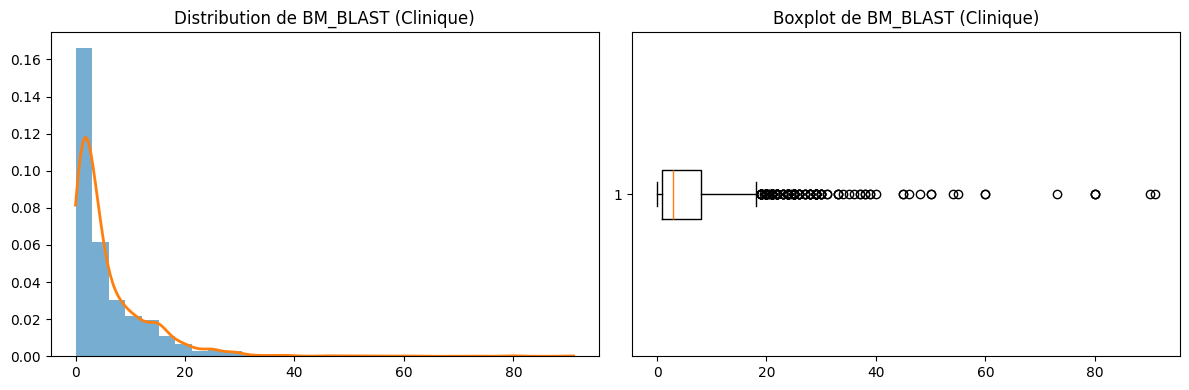

Valeurs manquantes pour BM_BLAST: 79


In [12]:
plot_numerical_distributions(df_train, ['BM_BLAST'], title_suffix="(Clinique)")
print(f"Valeurs manquantes pour BM_BLAST: {df_train['BM_BLAST'].isnull().sum()}")

**Prétraitement et Justification:**
* **Valeurs manquantes:** Imputation par la médiane. La médiane est choisie car elle est robuste aux valeurs extrêmes, qui pourraient être présentes. Un flag de valeur manquante (`BM_BLAST_missing`) sera aussi créé.
* **Outliers:** Des flags d'outliers (`BM_BLAST_high_outlier`, `BM_BLAST_low_outlier`) seront créés avec `add_outlier_flags`.
* **Transformation:** Pas de transformation (ex: log) appliquée pour l'instant, la distribution peut être acceptable pour certains modèles (ex: arbres de décision). À réévaluer si les performances du modèle sont affectées.
* **Justification:** Assurer que toutes les lignes ont une valeur pour cette feature importante, tout en signalant les outliers potentiellement informatifs.

In [13]:
# Imputation (sera gérée par le SimpleImputer dans le pipeline)
# Flag de valeur manquante
df_train['BM_BLAST_missing'] = df_train['BM_BLAST'].isnull().astype(int)
# Application des flags d'outliers (après imputation potentielle si faite ici manuellement)
# Note: les flags d'outliers sont mieux appliqués sur des données déjà imputées.
# Pour le moment, on les applique sur les données telles quelles, puis l'imputation se fera dans le pipeline.
# df_train = add_outlier_flags(df_train, ['BM_BLAST'])

### 4.3 WBC (White Blood Cells / Globules Blancs)

**Description:** Numération des globules blancs.
**Type:** Numérique.
**Observation:**

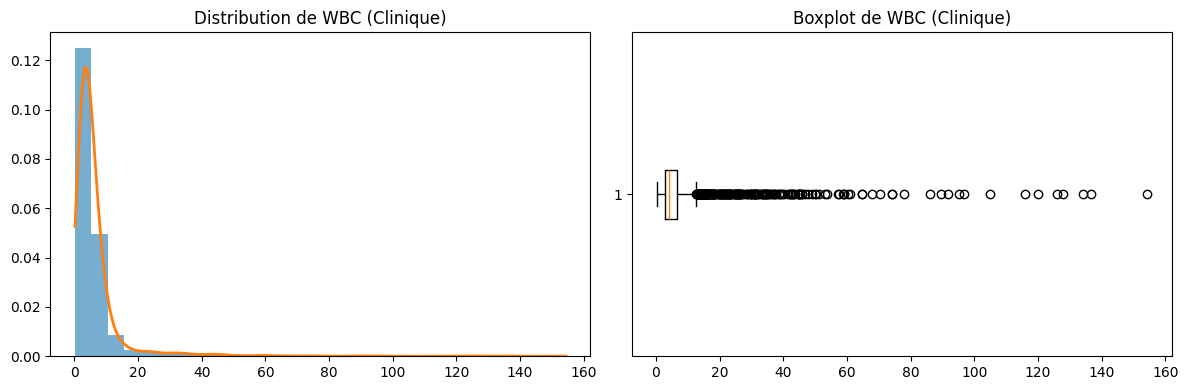

Valeurs manquantes pour WBC: 229


In [14]:
plot_numerical_distributions(df_train, ['WBC'], title_suffix="(Clinique)")
print(f"Valeurs manquantes pour WBC: {df_train['WBC'].isnull().sum()}")

**Prétraitement et Justification:**
* **Valeurs manquantes:** Imputation par la médiane + flag `WBC_missing`.
* **Outliers:** Flags d'outliers (`WBC_high_outlier`, `WBC_low_outlier`). La distribution est très étalée à droite (skewed).
* **Transformation:** Une transformation logarithmique (log1p pour gérer les zéros potentiels) est appliquée pour réduire l'asymétrie (`WBC_log`).
* **Justification:** La transformation log aide à normaliser la distribution, ce qui peut améliorer les performances de certains modèles (régression logistique, SVM, réseaux de neurones) et stabiliser la variance.

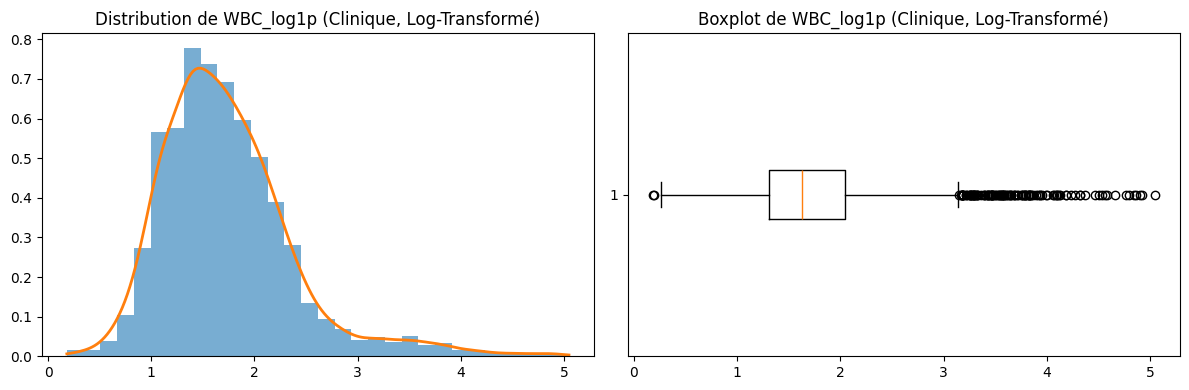

In [15]:
df_train['WBC_missing'] = df_train['WBC'].isnull().astype(int)
# df_train = add_outlier_flags(df_train, ['WBC'])
df_train['WBC_log1p'] = np.log1p(df_train['WBC']) # Appliqué avant imputation pour visualiser
# L'imputation pour WBC_log se fera sur cette colonne transformée.

plot_numerical_distributions(df_train, ['WBC_log1p'], title_suffix="(Clinique, Log-Transformé)")

df_train.drop('WBC', axis=1, inplace=True)

### 4.4 ANC (Absolute Neutrophil Count / Nombre Absolu de Neutrophiles)

**Description:** Sous-type de globules blancs.
**Type:** Numérique.
**Observation:**

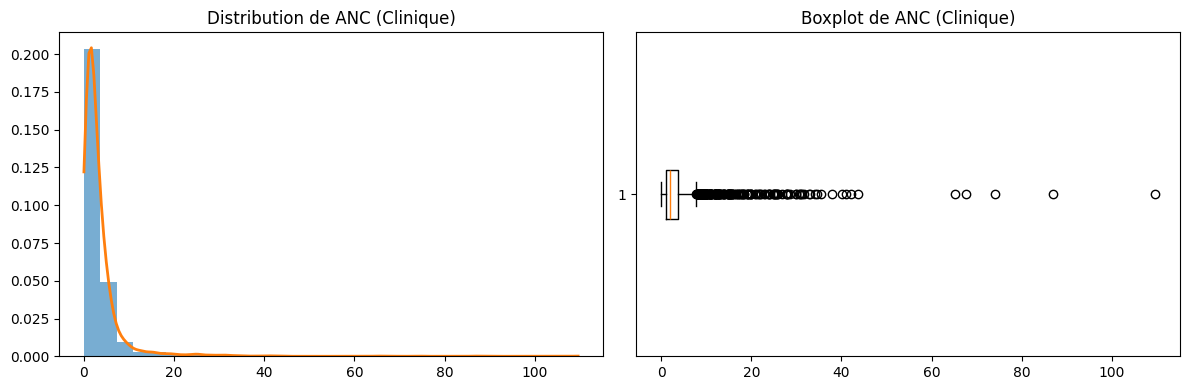

Valeurs manquantes pour ANC: 141


In [16]:
plot_numerical_distributions(df_train, ['ANC'], title_suffix="(Clinique)")
print(f"Valeurs manquantes pour ANC: {df_train['ANC'].isnull().sum()}")

**Prétraitement et Justification:** Similaire à WBC.
* **Valeurs manquantes:** Imputation par la médiane + flag `ANC_missing`.
* **Outliers:** Flags d'outliers (`ANC_high_outlier`, `ANC_low_outlier`).
* **Transformation:** Transformation `log1p` (`ANC_log`).
* **Justification:** Mêmes raisons que pour WBC.

In [17]:
df_train['ANC_missing'] = df_train['ANC'].isnull().astype(int)
# df_train = add_outlier_flags(df_train, ['ANC'])
df_train['ANC_log1p'] = np.log1p(df_train['ANC'])

plot_numerical_distributions(df_train, ['ANC_log'], title_suffix="(Clinique, Log-Transformé)")

df_train.drop(['ANC'], axis=1, inplace=True)

Colonne ANC_log absente du DataFrame.


### 4.5 MONOCYTES

**Description:** Taux de monocytes.
**Type:** Numérique.
**Observation:**

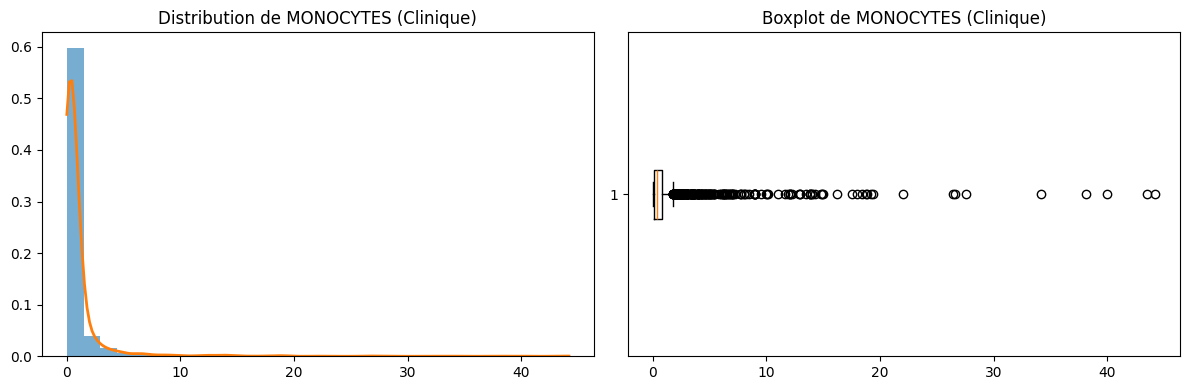

Valeurs manquantes pour MONOCYTES: 544 (17.14%)


In [18]:
plot_numerical_distributions(df_train, ['MONOCYTES'], title_suffix="(Clinique)")
print(f"Valeurs manquantes pour MONOCYTES: {df_train['MONOCYTES'].isnull().sum()} ({df_train['MONOCYTES'].isnull().mean()*100:.2f}%)")

**Prétraitement et Justification:** Taux de valeurs manquantes notable.
* **Valeurs manquantes:** Imputation par la médiane + flag `MONOCYTES_missing`.
* **Outliers:** Flags d'outliers (`MONOCYTES_high_outlier`, `MONOCYTES_low_outlier`).
* **Transformation:** Transformation `log1p` (`MONOCYTES_log`).
* **Justification:** Gérer le nombre important de manquants et la distribution asymétrique.

In [19]:
from sklearn.linear_model import LinearRegression

df_train['MONOCYTES_missing'] = df_train['MONOCYTES'].isnull().astype(int)
# df_train = add_outlier_flags(df_train, ['MONOCYTES'])
df_train['MONOCYTES_log1p'] = np.log1p(df_train['MONOCYTES']) # Imputation se fera sur cette colonne transformée dans le pipeline

train_data = df_train[['WBC_log1p', 'ANC_log1p', 'MONOCYTES_log1p']].dropna()

X_train = train_data[['WBC_log1p', 'ANC_log1p']]
y_train = train_data['MONOCYTES_log1p']

# Régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)

# Prédiction pour les lignes où MONOCYTES est NaN mais WBC et ANC sont présents
mask_pred = df_train['MONOCYTES_log1p'].isna() & df_train['WBC_log1p'].notna() & df_train['ANC_log1p'].notna()
X_pred = df_train.loc[mask_pred, ['WBC_log1p', 'ANC_log1p']]

predicted_mono_log1p = model.predict(X_pred)

# Imputation
df_train.loc[mask_pred, 'MONOCYTES_log1p'] = predicted_mono_log1p

plot_numerical_distributions(df_train, ['MONOCYTES_log'], title_suffix="(Clinique, Log-Transformé)")

df_train.drop(['MONOCYTES'], axis=1, inplace=True)

Colonne MONOCYTES_log absente du DataFrame.


### 4.6 HB (Hemoglobin / Hémoglobine)

**Description:** Taux d'hémoglobine.
**Type:** Numérique.
**Observation:**

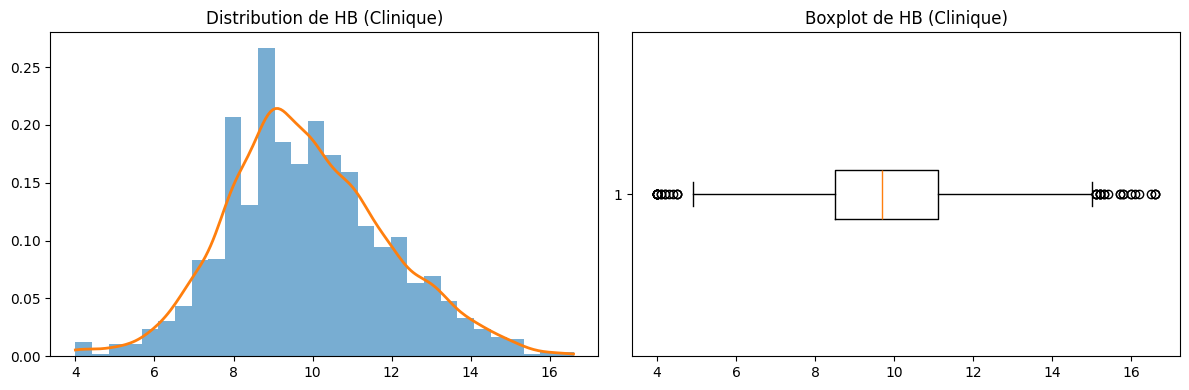

Valeurs manquantes pour HB: 75


In [20]:
plot_numerical_distributions(df_train, ['HB'], title_suffix="(Clinique)")
print(f"Valeurs manquantes pour HB: {df_train['HB'].isnull().sum()}")

**Prétraitement et Justification:**
* **Valeurs manquantes:** Imputation par la médiane + flag `HB_missing`.
* **Outliers:** Flags d'outliers (`HB_high_outlier`, `HB_low_outlier`).
* **Transformation:** La distribution semble moins asymétrique que WBC/ANC. Une transformation log n'est pas appliquée d'office mais pourrait être testée.
* **Justification:** Feature standard, traitement classique des manquants et outliers.

In [21]:
df_train['HB_missing'] = df_train['HB'].isnull().astype(int)
# df_train = add_outlier_flags(df_train, ['HB'])

### 4.7 PLT (Platelets / Plaquettes)

**Description:** Nombre de plaquettes sanguines.
**Type:** Numérique.
**Observation:**

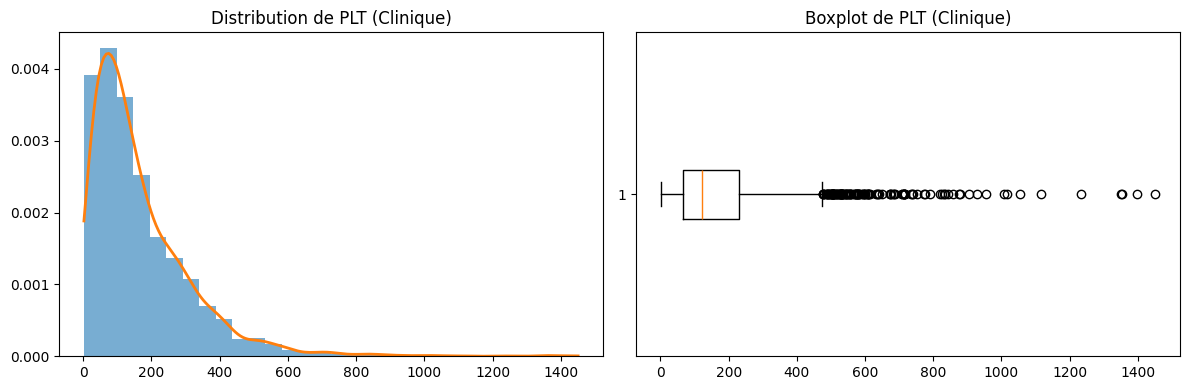

Valeurs manquantes pour PLT: 86


In [22]:
plot_numerical_distributions(df_train, ['PLT'], title_suffix="(Clinique)")
print(f"Valeurs manquantes pour PLT: {df_train['PLT'].isnull().sum()}")

**Prétraitement et Justification:**
* **Valeurs manquantes:** Imputation par la médiane + flag `PLT_missing`.
* **Outliers:** Flags d'outliers (`PLT_high_outlier`, `PLT_low_outlier`).
* **Transformation:** Distribution un peu asymétrique. Une transformation log (`PLT_log`) peut être envisagée.
* **Justification:** Standard.

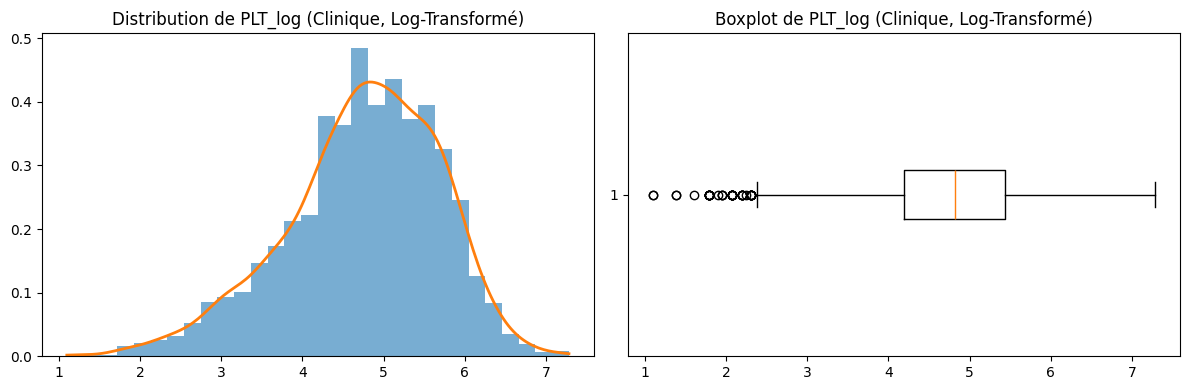

In [23]:
df_train['PLT_missing'] = df_train['PLT'].isnull().astype(int)
# df_train = add_outlier_flags(df_train, ['PLT'])
df_train['PLT_log'] = np.log1p(df_train['PLT']) # Ajout d'une version log

plot_numerical_distributions(df_train, ['PLT_log'], title_suffix="(Clinique, Log-Transformé)")

df_train.drop(['PLT'], axis=1, inplace=True)

### 4.8 CYTOGENETICS

**Description:** Résultats d'analyse cytogénétique, informant sur les anomalies chromosomiques.
**Type:** Textuel/Catégoriel complexe.
**Observation:**


La colonne `CYTOGENETICS` contient des informations textuelles sur les anomalies chromosomiques détectées chez les patients (translocations, inversions, délétions, trisomies, etc.). Ces anomalies sont fortement liées au pronostic clinique et sont classées selon des critères comme ceux de l’ELN 2022.

Nous transformons cette colonne texte en variables numériques exploitables en :
- Extrayant des motifs standards (t(8;21), del(5q), etc.) ;
- Comptant les occurrences par type d’anomalie ;
- Ajoutant des flags (karyotype complexe, normal, ELN défavorable...) ;
- Calculant la médiane de la ploidie et le sexe du patient si précisé.

Les variables générées sont ensuite analysées pour :
- Quantifier leur fréquence dans le jeu de données ;
- Estimer leur pouvoir prédictif sur l’événement de décès (`death_event`).

Du fait de leur complexité et de la proportion acceptable de missing_values (11%), we have decided to remove lines with missing Cytogenetics.

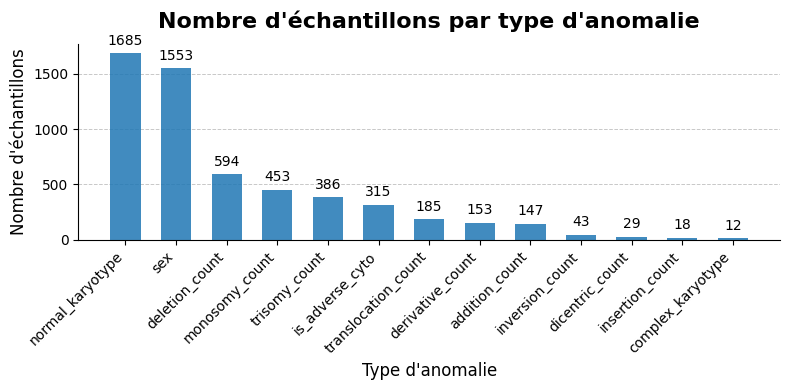

['ID', 'OS_YEARS', 'OS_STATUS']


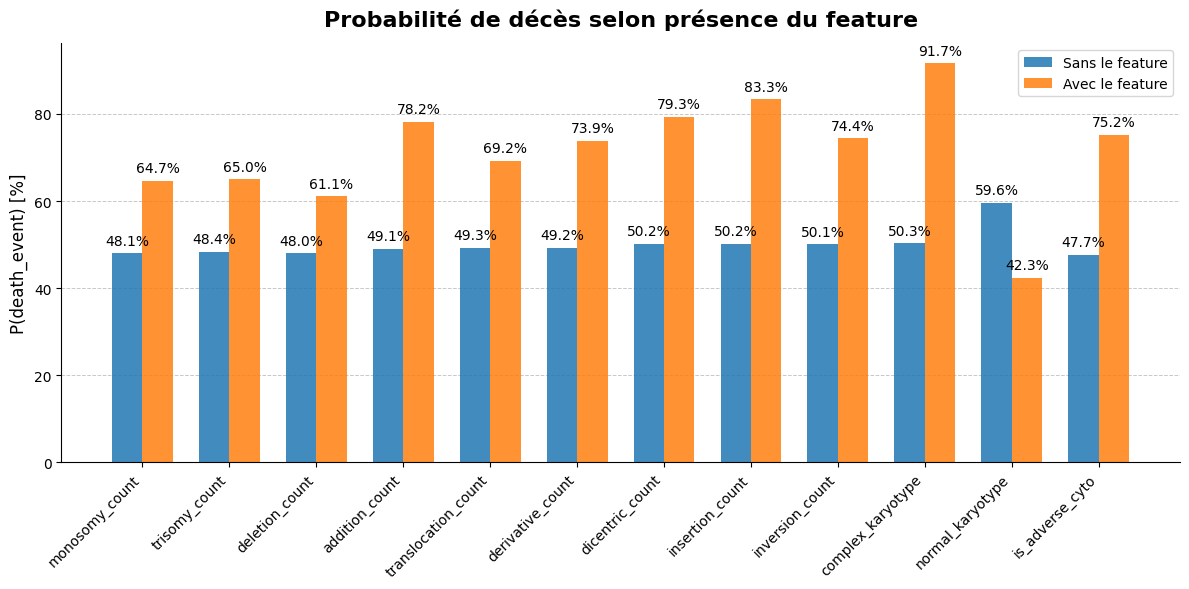

In [24]:
# Enrichissement avec les features CYTOGENETICS
features_cyto_train = extract_cyto_features(df_train, 'CYTOGENETICS')
#features_cyto_test  = extract_cyto_features(df_test, 'CYTOGENETICS')

df_train = pd.concat([df_train, features_cyto_train], axis=1)
#df_test  = pd.concat([df_test, features_cyto_test], axis=1)

# Affichage des features extraites
cyto_cols = features_cyto_train.columns.tolist()
df_train[cyto_cols].head()

# Analyse des anomalies cytogénétiques
anomaly_cols = [
    'monosomy_count','trisomy_count','deletion_count','addition_count',
    'translocation_count','derivative_count','dicentric_count',
    'insertion_count','inversion_count','complex_karyotype','normal_karyotype',
    'is_adverse_cyto','sex'
]

# Compter le nombre d’échantillons ayant au moins 1 événement
presence_counts = (df_train[anomaly_cols] > 0).sum()
presence_counts = presence_counts.sort_values(ascending=False)

# Tracé du bar plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(presence_counts.index, presence_counts.values, width=0.6, alpha=0.85)
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_title("Nombre d'échantillons par type d'anomalie", fontsize=16, fontweight='bold', pad=12)
ax.set_ylabel("Nombre d'échantillons", fontsize=12)
ax.set_xlabel("Type d'anomalie", fontsize=12)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

# Calcul de la mortalité conditionnelle
df_target2 = df_target.copy()
print(df_target2.columns.tolist())
df_train = df_train.drop(columns=[col for col in ['OS_STATUS', 'OS_YEARS'] if col in df_train.columns])
df_train = df_train.merge(df_target, on='ID')
df_train['death_event'] = (df_train['OS_STATUS'] == 1).astype(int)

features = [
    'monosomy_count','trisomy_count','deletion_count','addition_count',
    'translocation_count','derivative_count','dicentric_count',
    'insertion_count','inversion_count','complex_karyotype',
    'normal_karyotype','is_adverse_cyto'
]

proba_absent = []
proba_present = []
for feat in features:
    present_mask = df_train[feat] > 0
    proba_present.append(df_train.loc[present_mask, 'death_event'].mean() * 100)
    proba_absent.append(df_train.loc[~present_mask, 'death_event'].mean() * 100)

x = np.arange(len(features))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
bars_abs = ax.bar(x - width/2, proba_absent, width, alpha=0.85, label='Sans le feature')
bars_pres = ax.bar(x + width/2, proba_present, width, alpha=0.85, label='Avec le feature')

ax.bar_label(bars_abs, fmt='%.1f%%', padding=4, fontsize=10)
ax.bar_label(bars_pres, fmt='%.1f%%', padding=4, fontsize=10)

ax.set_title("Probabilité de décès selon présence du feature", fontsize=16, fontweight='bold', pad=12)
ax.set_ylabel("P(death_event) [%]", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right', fontsize=10)

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.legend()
plt.tight_layout()
plt.show()

In [25]:
df_train.drop(['CYTOGENETICS'], axis=1, inplace=True)

### 4.9 Création de Features d'Interaction Cliniques

**Justification:** Certains ratios ou combinaisons de variables cliniques peuvent avoir une signification biologique ou pronostique plus forte que les variables prises isolément.

In [26]:
# Application de la fonction pour créer des interactions
df_train = add_interaction_features(df_train) # Ex: ANC_WBC_ratio

if 'ANC_WBC_ratio' in df_train.columns:
    print("\nDistribution du ratio ANC/WBC:")
    plot_numerical_distributions(df_train, ['ANC_WBC_ratio'])
    # Gérer les infinis ou NaNs potentiels si WBC était 0 et non géré par epsilon dans la fonction.
    df_train['ANC_WBC_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
    # L'imputation des NaNs pour ce ratio se fera dans le pipeline global.

### 4.10 Corrélations entre les variables cliniques (après transformations initiales)



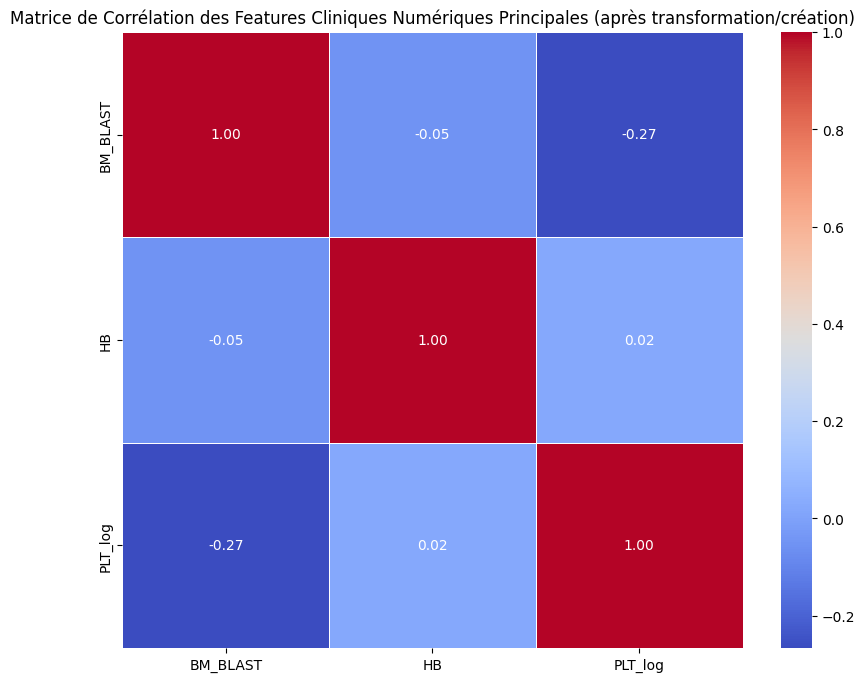

In [27]:
numerical_cols_clinical = df_train.select_dtypes(include=np.number).columns.tolist()
# Exclure les identifiants, cibles brutes, et flags binaires simples pour une meilleure lisibilité de la heatmap
cols_for_corr = [
    'BM_BLAST', 'WBC_log', 'ANC_log', 'MONOCYTES_log', 'HB', 'PLT_log', 'total_anomalies', 'ANC_WBC_ratio'
]
# S'assurer que toutes les colonnes existent et sont remplies (problème avec NaN)
cols_for_corr_existing = [col for col in cols_for_corr if col in df_train.columns]

# Imputation temporaire pour la heatmap de corrélation
# Une copie pour ne pas affecter df_train directement avec une imputation simple ici
df_corr_temp = df_train[cols_for_corr_existing].copy()
for col in df_corr_temp.columns:
    if df_corr_temp[col].isnull().any():
        df_corr_temp[col].fillna(df_corr_temp[col].median(), inplace=True)


if not df_corr_temp.empty:
    correlation_matrix_clinical = df_corr_temp.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix_clinical, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
    plt.title("Matrice de Corrélation des Features Cliniques Numériques Principales (après transformation/création)")
    plt.show()
else:
    print("Pas assez de colonnes numériques pour calculer la matrice de corrélation.")

In [28]:
import os

# Définir le chemin de sauvegarde vers le dossier souhaité
save_path = "/content/drive/MyDrive/QRT/2_csv/clinical_train_processed.csv"

# Sauvegarder le DataFrame
df_train.to_csv(save_path, index=False)

print(f"df_train a été sauvegardé à : {save_path}")

df_train a été sauvegardé à : /content/drive/MyDrive/QRT/2_csv/clinical_train_processed.csv


# 5. Analyse Exploratoire et Prétraitement des Données Moléculaires (df_molecular)

Les données moléculaires contiennent des informations sur les mutations génétiques pour chaque patient. Un patient peut avoir plusieurs mutations listées, donc plusieurs lignes.

Informations générales sur les données moléculaires (df_molecular):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10935 entries, 0 to 10934
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              10935 non-null  object 
 1   CHR             10821 non-null  object 
 2   START           10821 non-null  float64
 3   END             10821 non-null  float64
 4   REF             10821 non-null  object 
 5   ALT             10821 non-null  object 
 6   GENE            10935 non-null  object 
 7   PROTEIN_CHANGE  10923 non-null  object 
 8   EFFECT          10935 non-null  object 
 9   VAF             10846 non-null  float64
 10  DEPTH           10821 non-null  float64
dtypes: float64(4), object(7)
memory usage: 939.9+ KB

Statistiques descriptives pour les features numériques moléculaires:


,START,END,VAF,DEPTH
count,10821.000,10821.000,10846.000,10821.000
mean,80783256.162,80783257.544,0.305,1051.230
std,56426556.225,56426555.736,0.212,552.862
min,394899.000,394899.000,0.020,16.000
25%,31022441.000,31022442.000,0.103,660.000
50%,74732959.000,74732959.000,0.321,975.000
75%,115258747.000,115258747.000,0.442,1353.000
max,226252135.000,226252135.000,0.999,7156.000



Modalités pour les features catégorielles moléculaires (Top 5):

ID:


,count
ID,
P100244,17
P116704,15
P131816,14
P122415,14
P100305,13



CHR:


...

,count
GENE,
TET2,1663
ASXL1,951
SF3B1,775
DNMT3A,604
RUNX1,578



PROTEIN_CHANGE:


,count
PROTEIN_CHANGE,
p.?,529
p.K700E,426
p.G646fs*12,370
p.P95H,246
p.P95L,148



EFFECT:


,count
EFFECT,
non_synonymous_codon,5471
frameshift_variant,2877
stop_gained,1673
splice_site_variant,512
inframe_codon_loss,168


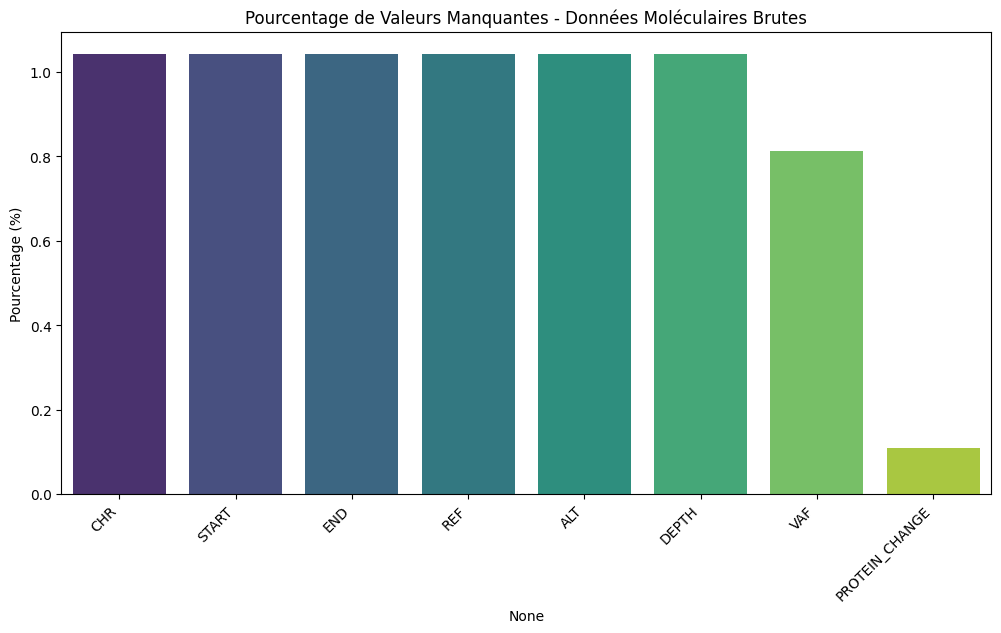

In [29]:
print("Informations générales sur les données moléculaires (df_molecular):")
df_molecular.info()

print("\nStatistiques descriptives pour les features numériques moléculaires:")
display(df_molecular.describe(include=np.number))

print("\nModalités pour les features catégorielles moléculaires (Top 5):")
for col in df_molecular.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    display(df_molecular[col].value_counts(dropna=False).head())

plot_missing_values(df_molecular, title="Données Moléculaires Brutes")

## 5.1 Prétraitement de GENE

**Description:** Nom du gène affecté par la mutation.
**Type:** Catégoriel.
**Observation:** Grand nombre de gènes uniques, certains très rares.

Nombre de gènes uniques: 124


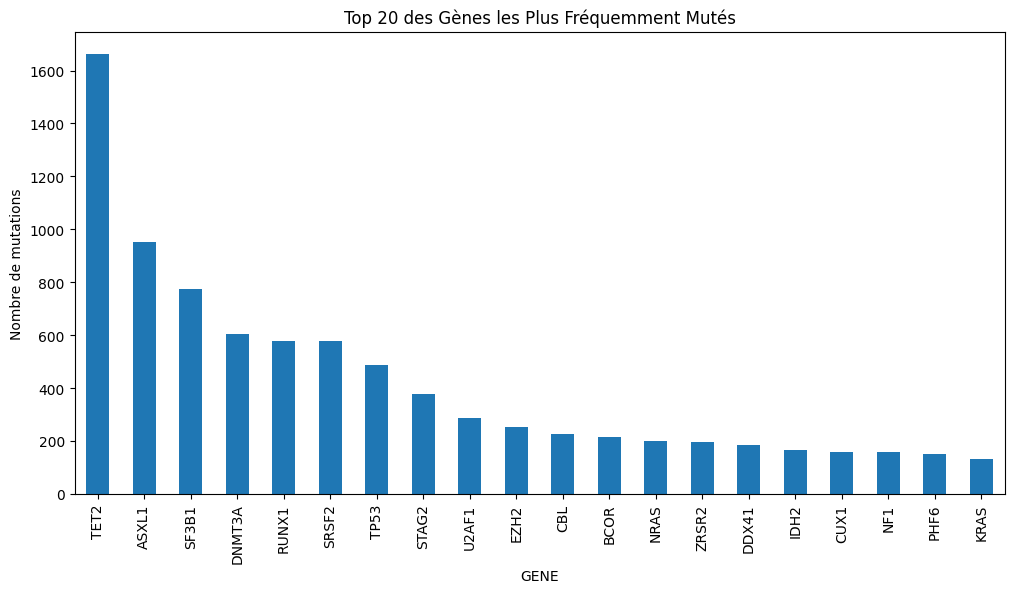

In [30]:
print(f"Nombre de gènes uniques: {df_molecular['GENE'].nunique()}")
plt.figure(figsize=(12,6))
df_molecular['GENE'].value_counts().head(20).plot(kind='bar') # Top 20 gènes
plt.title("Top 20 des Gènes les Plus Fréquemment Mutés")
plt.ylabel("Nombre de mutations")
plt.show()

**Prétraitement et Justification:**
* **Regroupement des gènes rares:** Les gènes avec peu de mutations (ex: < 10 occurrences) sont regroupés dans une catégorie "OTHER" en utilisant `process_gene_column`.
* **Justification:** Réduire la dimensionnalité et le bruit causé par des mutations très rares qui pourraient ne pas être généralisables.

In [31]:
df_molecular, rare_genes_list = process_gene_column(df_molecular, threshold=10) # threshold=10
print(f"\nNombre de gènes après regroupement en 'OTHER': {df_molecular['GENE_processed'].nunique()}")
print(f"Liste des {len(rare_genes_list)} gènes regroupés en 'OTHER' (échantillon): {rare_genes_list[:10]}")

# Remplacer la colonne GENE originale par la version traitée pour l'agrégation
df_molecular['GENE'] = df_molecular['GENE_processed']
df_molecular.drop(columns=['GENE_processed'], inplace=True)


Nombre de gènes après regroupement en 'OTHER': 83
Liste des 42 gènes regroupés en 'OTHER' (échantillon): ['ZMYM3', 'DNMT3B', 'CSF1R', 'CHEK2', 'STAT5A', 'RAC1', 'ARID1A', 'SPRED2', 'KDM5C', 'NOTCH2']


## 5.2 Prétraitement de PROTEIN_CHANGE

**Description:** Changement spécifique au niveau de la protéine.
**Type:** Catégoriel complexe.
**Observation:** Très haute cardinalité.

In [32]:
print(f"Nombre de PROTEIN_CHANGE uniques: {df_molecular['PROTEIN_CHANGE'].nunique()}")

Nombre de PROTEIN_CHANGE uniques: 4686


**Prétraitement et Justification:**
* **Encodage et regroupement:** Utilisation de `encode_protein_change` pour standardiser les notations, regrouper des familles de mutations, et marquer les mutations rares ou inconnues.
* **Justification:** Réduire la cardinalité tout en conservant l'information des mutations les plus pertinentes ou fréquentes.

In [33]:
df_molecular['PROTEIN_CHANGE_encoded'] = df_molecular['PROTEIN_CHANGE'].apply(encode_protein_change)
print(f"\nNombre de PROTEIN_CHANGE uniques après encodage: {df_molecular['PROTEIN_CHANGE_encoded'].nunique()}")
display(df_molecular['PROTEIN_CHANGE_encoded'].value_counts().head(10))
# Cette colonne sera utilisée si on décide de pivoter sur les changements protéiques.
# Pour l'agrégation simple, on se concentre souvent sur les gènes.


Nombre de PROTEIN_CHANGE uniques après encodage: 8


,count
PROTEIN_CHANGE_encoded,
rare,8873
p.P95X,552
unknown,529
p.K700E,426
p.G646fs*12,370
MLL_PTD,89
p.V617F,84
missing,12


## 5.3 VAF (Variant Allele Frequency) et DEPTH (Profondeur de Lecture)

**Description:**
* `VAF`: Fréquence de l'allèle muté. Indicateur de la proportion de cellules portant la mutation.
* `DEPTH`: Nombre total de lectures génomiques à cet emplacement. Indicateur de fiabilité.
**Type:** Numérique.
**Observation:**

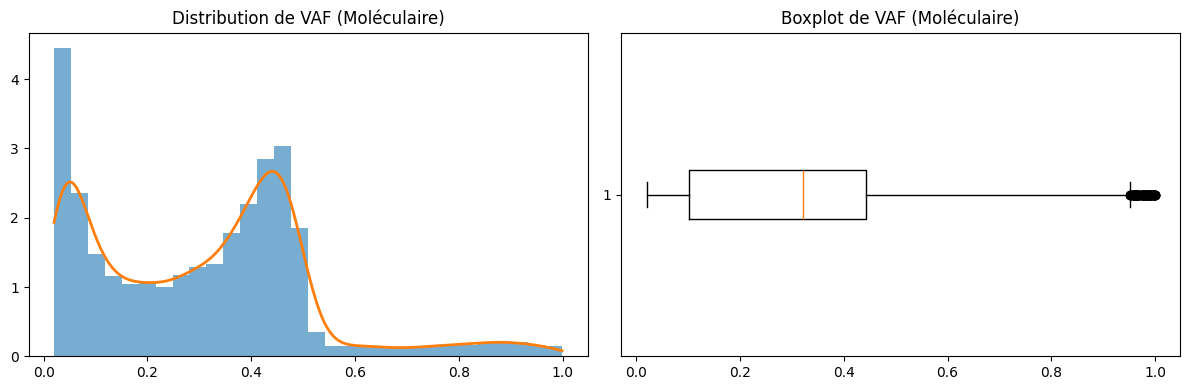

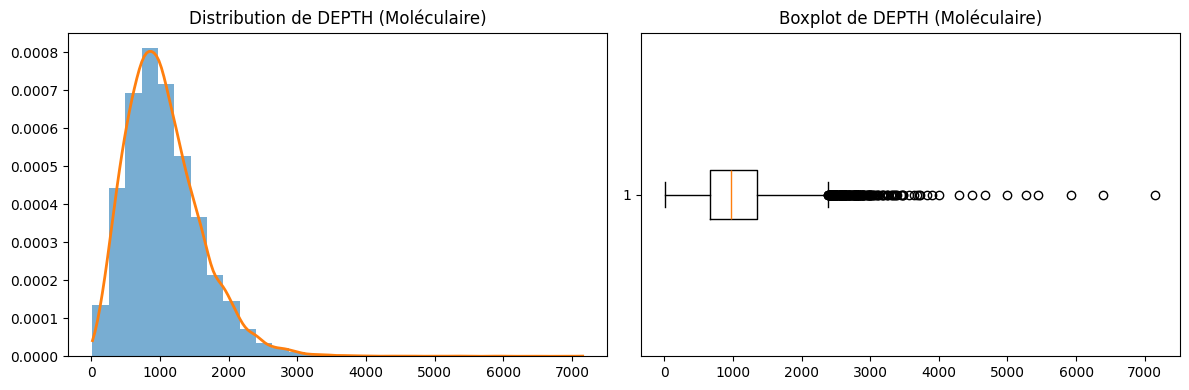

In [34]:
plot_numerical_distributions(df_molecular, ['VAF', 'DEPTH'], title_suffix="(Moléculaire)")

**Prétraitement et Justification:**
* **Valeurs manquantes:** Si présentes, elles seront gérées lors de l'agrégation (souvent, les fonctions d'agrégation les ignorent par défaut, ou on pourrait imputer avant agrégation si pertinent).
* **Utilisation:** Ces features seront agrégées par patient (moyenne, max, min pour VAF; moyenne pour DEPTH) pour résumer le profil mutationnel.
* **Justification:** Les statistiques de VAF peuvent informer sur la clonalité des mutations. Une DEPTH élevée augmente la confiance dans la détection de la mutation.

In [35]:
# Pas de transformation directe ici, car elles seront agrégées.
# On vérifie les manquants avant agrégation.
print(f"Valeurs manquantes VAF: {df_molecular['VAF'].isnull().sum()}")
print(f"Valeurs manquantes DEPTH: {df_molecular['DEPTH'].isnull().sum()}")

# Stratégie d'imputation avant agrégation si nécessaire :
# df_molecular['VAF'].fillna(df_molecular['VAF'].median(), inplace=True) # Exemple
# df_molecular['DEPTH'].fillna(df_molecular['DEPTH'].median(), inplace=True) # Exemple
# Pour ce notebook, on laisse les fonctions d'agrégation gérer les NaNs (souvent en les ignorant).

Valeurs manquantes VAF: 89
Valeurs manquantes DEPTH: 114


## 5.4 Autres colonnes moléculaires (CHR, START, END, REF, ALT, EFFECT)

**Description:**
* `CHR`, `START`, `END`: Coordonnées chromosomiques de la mutation.
* `REF`, `ALT`: Allèles de référence et alternatif.
* `EFFECT`: Impact prédit de la mutation (ex: missense, frameshift).
**Observation:**

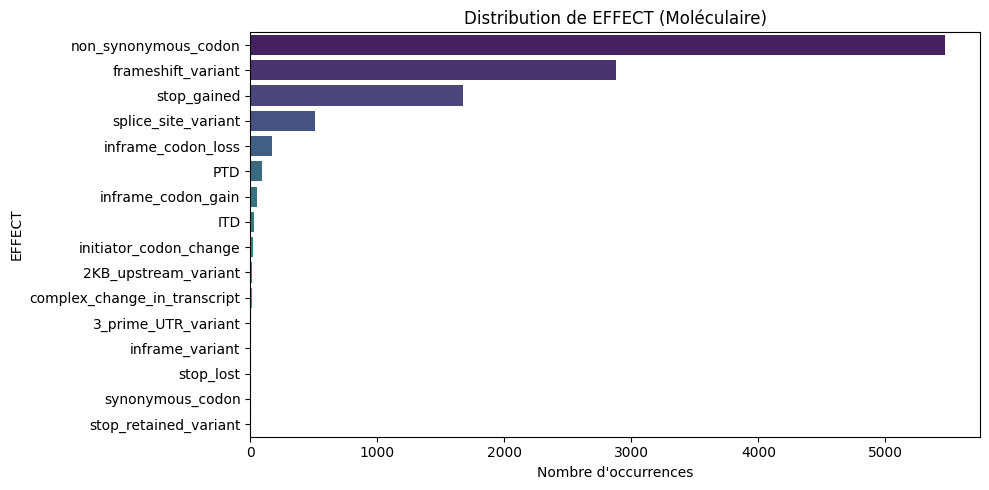

,proportion
EFFECT,
non_synonymous_codon,0.500
frameshift_variant,0.263
stop_gained,0.153
splice_site_variant,0.047
inframe_codon_loss,0.015
PTD,0.008
inframe_codon_gain,0.005
ITD,0.002
initiator_codon_change,0.002


In [36]:
plot_categorical_distributions(df_molecular, ['EFFECT'], title_suffix="(Moléculaire)")
display(df_molecular['EFFECT'].value_counts(normalize=True).head(10))

**Prétraitement et Justification:**
* **`CHR`, `START`, `END`, `REF`, `ALT`:** Généralement utilisées pour identifier de manière unique une mutation ou pour l'annotation avec des bases de données externes. Moins souvent utilisées directement comme features dans les modèles, sauf si des loci spécifiques sont d'intérêt. Pour ce notebook, elles ne seront pas directement transformées en features agrégées autres que par leur contribution au comptage de mutations.
* **`EFFECT`:** Cette variable catégorielle est très informative. Pourrait être encodée (One-Hot) et agrégée (ex: compter le nombre de mutations "frameshift" par patient). Pour simplifier cette première version, nous ne l'agrégerons pas spécifiquement mais elle contribue au "nombre de mutations". Dans une itération future, on pourrait créer des features comme `count_frameshift_mutations`.
* **Justification:** Ces colonnes fournissent un contexte détaillé sur chaque mutation. `EFFECT` en particulier a un fort potentiel prédictif.

## 5.5 Agrégation des Données Moléculaires par Patient

**Justification:** Pour fusionner avec les données cliniques (une ligne par patient), nous devons agréger les informations moléculaires. Cela implique de calculer des statistiques (nombre de mutations, VAF moyen/max, etc.) et de flagger la présence de mutations dans des gènes clés.

In [37]:
# S'assurer que les ID de patients ayant des données moléculaires sont bien ceux présents dans df_molecular
molecular_ids_with_data = df_molecular['ID'].unique()

df_molecular_agg = aggregate_molecular_data(df_molecular)

print("Données moléculaires agrégées (df_molecular_agg):")
print("Dimensions:", df_molecular_agg.shape)
display(df_molecular_agg.head())

# Vérifier les colonnes créées et les types
df_molecular_agg.info()

Données moléculaires agrégées (df_molecular_agg):
Dimensions: (3026, 18)


,ID,VAF_mean,VAF_max,VAF_min,DEPTH_mean,unique_genes_count,mutation_count,has_mutation_in_NPM1,has_mutation_in_FLT3,has_mutation_in_DNMT3A,has_mutation_in_TP53,has_mutation_in_CEBPA,has_mutation_in_TET2,has_mutation_in_ASXL1,has_mutation_in_SF3B1,has_mutation_in_IDH1,has_mutation_in_IDH2,has_mutation_in_RUNX1
0,P100000,0.301,0.773,0.022,834.500,6,6,0,0,1,0,0,1,0,0,0,0,0
1,P100001,0.260,0.418,0.101,536.000,2,2,0,0,0,0,0,0,0,0,0,0,0
2,P100002,0.397,0.597,0.197,398.500,2,2,0,0,0,1,0,0,0,0,0,0,0
3,P100004,0.469,0.469,0.469,1296.000,1,1,0,0,0,0,0,0,0,0,0,0,0
4,P100006,0.169,0.372,0.056,591.400,5,5,0,0,0,0,0,1,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3026 entries, 0 to 3025
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3026 non-null   object 
 1   VAF_mean                3024 non-null   float64
 2   VAF_max                 3024 non-null   float64
 3   VAF_min                 3024 non-null   float64
 4   DEPTH_mean              3024 non-null   float64
 5   unique_genes_count      3026 non-null   int64  
 6   mutation_count          3026 non-null   int64  
 7   has_mutation_in_NPM1    3026 non-null   int64  
 8   has_mutation_in_FLT3    3026 non-null   int64  
 9   has_mutation_in_DNMT3A  3026 non-null   int64  
 10  has_mutation_in_TP53    3026 non-null   int64  
 11  has_mutation_in_CEBPA   3026 non-null   int64  
 12  has_mutation_in_TET2    3026 non-null   int64  
 13  has_mutation_in_ASXL1   3026 non-null   int64  
 14  has_mutation_in_SF3B1   3026 non-null   

# 6. Fusion Finale des Données et Création de Features Post-Fusion

Nous allons maintenant fusionner les données cliniques prétraitées (`df_train`) avec les données moléculaires agrégées (`df_molecular_agg`).

In [38]:
df_final_train = df_train.merge(df_molecular_agg, on="ID", how="left")

print("Dimensions de df_final_train après fusion avec données moléculaires agrégées:", df_final_train.shape)
display(df_final_train.head())

Dimensions de df_final_train après fusion avec données moléculaires agrégées: (3173, 70)


,ID,BM_BLAST,HB,CENTER_CCH,CENTER_CGM,CENTER_DUS,CENTER_DUTH,CENTER_FLO,CENTER_FUCE,CENTER_GESMD,CENTER_HIAE,CENTER_HMS,CENTER_ICO,CENTER_IHBT,CENTER_KI,CENTER_MSK,CENTER_MUV,CENTER_PV,CENTER_REL,CENTER_RMCN,CENTER_ROM,CENTER_TUD,CENTER_UMG,CENTER_UOB,CENTER_UOXF,CENTER_VU,BM_BLAST_missing,WBC_missing,WBC_log1p,ANC_missing,ANC_log1p,MONOCYTES_missing,MONOCYTES_log1p,HB_missing,PLT_missing,PLT_log,sex,ploidy_median,monosomy_count,trisomy_count,deletion_count,addition_count,translocation_count,derivative_count,dicentric_count,insertion_count,inversion_count,complex_karyotype,normal_karyotype,is_adverse_cyto,OS_YEARS,OS_STATUS,death_event,VAF_mean,VAF_max,VAF_min,DEPTH_mean,unique_genes_count,mutation_count,has_mutation_in_NPM1,has_mutation_in_FLT3,has_mutation_in_DNMT3A,has_mutation_in_TP53,has_mutation_in_CEBPA,has_mutation_in_TET2,has_mutation_in_ASXL1,has_mutation_in_SF3B1,has_mutation_in_IDH1,has_mutation_in_IDH2,has_mutation_in_RUNX1
0,P132697,14.000,7.600,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,0,0,1.335,0,0.182,0,0.531,0,0,4.787,1.000,46.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,False,1.115,1.000,1,0.252,0.422,0.030,1708.222,8.000,9.000,0.000,1.000,1.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000
1,P132698,1.000,11.600,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,0,0,2.128,0,1.224,0,0.095,0,0,3.761,0.000,46.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,False,4.929,0.000,0,0.273,0.282,0.266,1401.333,3.000,3.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000
2,P116889,15.000,14.200,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,0,0,1.548,0,1.131,0,0.095,0,0,4.407,1.000,46.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,True,2.044,0.000,0,0.039,0.048,0.035,1769.667,3.000,3.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
3,P132699,1.000,8.900,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,0,0,1.589,0,1.065,0,0.095,0,0,4.357,1.000,46.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,False,2.477,1.000,1,0.209,0.477,0.049,1145.909,9.000,11.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000
4,P132700,6.000,11.100,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,0,0,4.860,0,2.370,0,0.642,0,0,5.278,0.000,46.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,False,3.145,0.000,0,0.472,0.472,0.472,713.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000


In [39]:
import os


# Définir le chemin de sauvegarde vers le dossier souhaité
save_path = "/content/drive/MyDrive/QRT/2_csv/full_train_processed.csv"

# Sauvegarder le DataFrame
df_final_train.to_csv(save_path, index=False)

print(f"df_final_train a été sauvegardé à : {save_path}")

df_final_train a été sauvegardé à : /content/drive/MyDrive/QRT/2_csv/full_train_processed.csv


## 6.1 Création du Flag has_molecular_data

**Justification:** Savoir si un patient avait ou non des données moléculaires disponibles peut être une information en soi. Cela pourrait refléter des différences dans la prise en charge, la disponibilité des tests, ou la nature de la maladie.

In [40]:
# La fonction add_missing_molecular_flag nécessite les ID uniques des données moléculaires originales
df_final_train = add_missing_molecular_flag(df_final_train, molecular_ids_with_data)
print("\nDistribution de 'has_molecular_data':")
print(df_final_train['has_molecular_data'].value_counts())


Distribution de 'has_molecular_data':
has_molecular_data
1    2910
0     263
Name: count, dtype: int64


## 6.2 Nettoyage final des colonnes

Certaines colonnes ont servi à la création d'autres et peuvent être supprimées si elles ne sont plus utiles directement comme features (ex: `CYTOGENETICS` brute, `PROTEIN_CHANGE` brute des données moléculaires car déjà agrégées ou encodées).
Les colonnes `OS_YEARS` sont aussi retirées car `OS_STATUS` est notre cible.
L'identifiant `ID` est retiré des features.

In [41]:
# # Colonnes à retirer avant la modélisation
# cols_to_drop_final = ['ID'] # CYTOGENETICS brute est remplacée par ses extractions

# # Colonnes moléculaires originales qui étaient dans df_molecular mais pas dans df_molecular_agg
# # et qui pourraient être présentes si la fusion a mal géré des suffixes (peu probable avec `on="ID"`)
# # ou si on veut explicitement retirer les colonnes non agrégées.
# # Ici, on se concentre sur celles de df_final_train.

# # On vérifie que les colonnes à dropper existent bien
# existing_cols_to_drop = [col for col in cols_to_drop_final if col in df_final_train.columns]
# df_final_train.drop(columns=existing_cols_to_drop, inplace=True, errors='ignore')

# print(f"\nDimensions de df_final_train après suppression des colonnes inutiles: {df_final_train.shape}")
# display(df_final_train.head())

# 7. Préparation Finale des Données pour la Modélisation
## 7.1 Séparation des Features (X) et de la Cible (y)

In [42]:
# Installer les dépendances requises
!apt-get install -y libglib2.0-0 libsm6 libxext6 libxrender-dev

# Installer scikit-survival via pip avec les bons paramètres
!pip install -U scikit-survival

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libsm6 is already the newest version (2:1.2.3-1build2).
libxext6 is already the newest version (2:1.3.4-1build1).
libxrender-dev is already the newest version (1:0.9.10-1build4).
libxrender-dev set to manually installed.
libglib2.0-0 is already the newest version (2.72.4-0ubuntu2.4).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.3/298.3 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.1/220.1 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.3 MB/s eta 0:00:00
  Attempting uninstall: osqp
    Found existing installation: osqp 1.0.4
    Uninstalling osqp-1.0.4:
      Successfully uninstalled osqp-1.0.4


## 7.2 Identification des Colonnes Numériques et Catégorielles Finales

Après toutes les transformations, nous devons identifier les types de colonnes pour appliquer les bons prétraitements (scaling pour les numériques, encodage pour les catégorielles).

In [43]:
pip install xgboost

In [44]:
import pandas as pd
from sksurv.util import Surv
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer
from xgboost import XGBRegressor
from sksurv.metrics import concordance_index_ipcw

base_path = "/content/drive/MyDrive/QRT"
path_output   = f"{base_path}/2_csv/output3.csv"

In [45]:
X = df_final_train.drop(columns=["ID", "OS_STATUS", "OS_YEARS"])
y = Surv.from_dataframe("OS_STATUS", "OS_YEARS", df_final_train)

In [46]:
# === 3) Split train / validation ===
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=None  # ou stratify=df_final_train["OS_STATUS"] si souhaité
)
print(f"Train : {X_train.shape}, Val : {X_val.shape}")

Train : (2538, 68), Val : (635, 68)


In [47]:
# Identification des types de colonnes dans X
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
# S'assurer que les booléens sont traités comme numériques ou catégoriques selon le besoin.
# Souvent, ils sont convertis en int (0/1) et traités comme numériques.
# Si des booléens sont restés, X.select_dtypes(include=np.bool_).columns.tolist()

# Création des transformateurs
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # ou 'mean'
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # ou 'constant', fill_value='missing'
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # sparse_output=False pour retourner un array dense
])

# Création du ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # 'drop' ou 'passthrough' pour les colonnes non spécifiées
)

In [48]:
# Fit le préprocesseur uniquement sur le train
preprocessor.fit(X_train)
X_train_p = preprocessor.transform(X_train)
X_val_p   = preprocessor.transform(X_val)

print(f"Train : {X_train_p.shape}, Val : {X_val_p.shape}")

Train : (2538, 68), Val : (635, 68)


In [49]:
path_clinical_test = f"{base_path}/0_data/clinical_test.csv"
path_molecular_test = f"{base_path}/0_data/molecular_test.csv"

clin_test = safe_read_csv(path_clinical_test)
mol_test = safe_read_csv(path_molecular_test)

#################################################################



clin_test['CENTER'] = clin_test['CENTER'].astype('category')

clin_test = pd.get_dummies(clin_test,
                          columns=['CENTER'],
                          prefix='CENTER',
                          dummy_na=False)

clin_test['BM_BLAST_missing'] = clin_test['BM_BLAST'].isnull().astype(int)

########

clin_test['WBC_missing'] = clin_test['WBC'].isnull().astype(int)
# clin_test = add_outlier_flags(clin_test, ['WBC'])
clin_test['WBC_log1p'] = np.log1p(clin_test['WBC']) # Appliqué avant imputation pour visualiser
clin_test.drop('WBC', axis=1, inplace=True)

########

clin_test['ANC_missing'] = clin_test['ANC'].isnull().astype(int)
# clin_test = add_outlier_flags(clin_test, ['ANC'])
clin_test['ANC_log1p'] = np.log1p(clin_test['ANC'])
clin_test.drop(['ANC'], axis=1, inplace=True)

########

clin_test['MONOCYTES_missing'] = clin_test['MONOCYTES'].isnull().astype(int)
# clin_test = add_outlier_flags(clin_test, ['MONOCYTES'])
clin_test['MONOCYTES_log1p'] = np.log1p(clin_test['MONOCYTES']) # Imputation se fera sur cette colonne transformée dans le pipeline

train_data = clin_test[['WBC_log1p', 'ANC_log1p', 'MONOCYTES_log1p']].dropna()

X_train1 = train_data[['WBC_log1p', 'ANC_log1p']]
y_train1 = train_data['MONOCYTES_log1p']

# Régression linéaire
model = LinearRegression()
model.fit(X_train1, y_train1)

# Prédiction pour les lignes où MONOCYTES est NaN mais WBC et ANC sont présents
mask_pred = clin_test['MONOCYTES_log1p'].isna() & clin_test['WBC_log1p'].notna() & clin_test['ANC_log1p'].notna()
X_pred = clin_test.loc[mask_pred, ['WBC_log1p', 'ANC_log1p']]

predicted_mono_log1p = model.predict(X_pred)

# Imputation
clin_test.loc[mask_pred, 'MONOCYTES_log1p'] = predicted_mono_log1p
clin_test.drop(['MONOCYTES'], axis=1, inplace=True)

#########

clin_test['HB_missing'] = clin_test['HB'].isnull().astype(int)
# clin_test = add_outlier_flags(clin_test, ['HB'])

##########

clin_test['PLT_missing'] = clin_test['PLT'].isnull().astype(int)
# clin_test = add_outlier_flags(clin_test, ['PLT'])
clin_test['PLT_log'] = np.log1p(clin_test['PLT']) # Ajout d'une version log
clin_test.drop(['PLT'], axis=1, inplace=True)

##########

# Enrichissement avec les features CYTOGENETICS
features_cyto_test = extract_cyto_features(clin_test, 'CYTOGENETICS')

clin_test = pd.concat([clin_test, features_cyto_test], axis=1)

# Affichage des features extraites
cyto_cols = features_cyto_test.columns.tolist()
clin_test[cyto_cols].head()

# Analyse des anomalies cytogénétiques
anomaly_cols = [
    'monosomy_count','trisomy_count','deletion_count','addition_count',
    'translocation_count','derivative_count','dicentric_count',
    'insertion_count','inversion_count','complex_karyotype','normal_karyotype',
    'is_adverse_cyto','sex'
]

clin_test.drop(['CYTOGENETICS'], axis=1, inplace=True)

################

clin_test = add_interaction_features(clin_test) # Ex: ANC_WBC_ratio

if 'ANC_WBC_ratio' in clin_test.columns:
    clin_test['ANC_WBC_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)

#######################################


mol_test, rare_genes_list = process_gene_column(mol_test, threshold=10) # threshold=10
print(f"\nNombre de gènes après regroupement en 'OTHER': {mol_test['GENE_processed'].nunique()}")
print(f"Liste des {len(rare_genes_list)} gènes regroupés en 'OTHER' (échantillon): {rare_genes_list[:10]}")

# Remplacer la colonne GENE originale par la version traitée pour l'agrégation
mol_test['GENE'] = mol_test['GENE_processed']
mol_test.drop(columns=['GENE_processed'], inplace=True)

mol_test['PROTEIN_CHANGE_encoded'] = mol_test['PROTEIN_CHANGE'].apply(encode_protein_change)

molecular_ids_with_data = mol_test['ID'].unique()

mol_test_agg = aggregate_molecular_data(mol_test)

##########################################

path_mol_test = f"{base_path}/2_csv/molecular_test_processed.csv"
mol_test2 = safe_read_csv(path_mol_test)
# mol_test_agg2 = aggregate_molecular_data(mol_test2)
##########################################
df_final_test = clin_test.merge(mol_test_agg, on="ID", how="left")

#df_final_test = add_missing_molecular_flag(df_final_test, molecular_ids_with_data)

X_test = df_final_test.drop(columns=['OS_STATUS','OS_YEARS'], errors='ignore')

# # 2. On aligne strictement sur les colonnes vues au fit
expected = preprocessor.feature_names_in_
X_test_aligned = X_test.reindex(columns=expected, fill_value=0)

# # # 3. On transforme et prédit
X_test_p = preprocessor.transform(X_test_aligned)

print(f"Train : {X_train_p.shape}, Val : {X_test_p.shape}")

Chargement de : /content/drive/MyDrive/QRT/0_data/clinical_test.csv
Chargement de : /content/drive/MyDrive/QRT/0_data/molecular_test.csv

Nombre de gènes après regroupement en 'OTHER': 44
Liste des 40 gènes regroupés en 'OTHER' (échantillon): ['SMC3', 'STAT3', 'BRCA2', 'PRPF8', 'KDM6A', 'RIT1', 'CALR', 'GNAS', 'ATM', 'ASXL2']
Chargement de : /content/drive/MyDrive/QRT/2_csv/molecular_test_processed.csv
Train : (2538, 68), Val : (1193, 68)


In [50]:
# ============================================================================
# Survival Modeling Notebook – XGB Cox amélioré + alternatives + diagnostics
# Timezone Europe/Paris – Mai 2025
# ============================================================================

# --- 0) Imports et setup global --------------------------------------------
import numpy as np
import pandas as pd
import shap
import time

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder,
    FunctionTransformer
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.metrics import make_scorer

from xgboost import XGBRegressor
from sksurv.util import Surv
from sksurv.metrics import (
    concordance_index_ipcw,
    concordance_index_censored,
    integrated_brier_score,
    cumulative_dynamic_auc
)
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest

print("Imports OK – démarrage…")

# --- 1) Vos données sont déjà nettoyées et disponibles ---------------------
# df_final_train, df_final_test doivent exister dans l'environnement.
# Ils contiennent déjà ID, OS_STATUS, OS_YEARS, ainsi que toutes les features prêtes.

print(f"Shapes initiales – Train: {df_final_train.shape}, Test: {df_final_test.shape}")

# --- 2) Séparation features / target & split validation --------------------
X = df_final_train.drop(columns=["ID", "OS_STATUS", "OS_YEARS"])
y = Surv.from_dataframe("OS_STATUS", "OS_YEARS", df_final_train)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=df_final_train["OS_STATUS"]
)
print(f"Après split – X_train: {X_train.shape}, X_val: {X_val.shape}")

# --- 3) Repérage des types de colonnes & skewness --------------------------
num_feats = X_train.select_dtypes(include=np.number).columns.tolist()
cat_feats = X_train.select_dtypes(include=['object','category']).columns.tolist()

skews = X_train[num_feats].skew().abs()
skewed_feats = skews[skews > 2].index.tolist()
nonskew_feats = [f for f in num_feats if f not in skewed_feats]

print(f"{len(num_feats)} numériques, {len(cat_feats)} catégorielles, {len(skewed_feats)} très skew")

# --- 4) Transformers personnalisés ------------------------------------------
class Winsorizer(TransformerMixin, BaseEstimator):
    """Clippe aux percentiles [1%, 99%] pour réduire l’impact des outliers."""
    def __init__(self, lower_pct=0.01, upper_pct=0.99):
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct

    def fit(self, X, y=None):
        self.lower_ = np.percentile(X, self.lower_pct * 100, axis=0)
        self.upper_ = np.percentile(X, self.upper_pct * 100, axis=0)
        return self

    def transform(self, X):
        return np.clip(X, self.lower_, self.upper_)

class RareCategoryGrouper(TransformerMixin, BaseEstimator):
    """Regroupe les modalités < seuil en 'Other'."""
    def __init__(self, min_frac=0.01):
        self.min_frac = min_frac

    def fit(self, X, y=None):
        self.keep_vals_ = {}
        for col in X.columns:
            freqs = X[col].value_counts(normalize=True)
            self.keep_vals_[col] = set(freqs[freqs >= self.min_frac].index)
        return self

    def transform(self, X):
        X2 = X.copy()
        for col, keep in self.keep_vals_.items():
            X2[col] = X2[col].where(X2[col].isin(keep), other="Other")
        return X2

# --- 5) Pipelines de prétraitement ------------------------------------------
numeric_skew_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("winsor", Winsorizer()),
    ("log1p", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("winsor", Winsorizer()),
    ("scaler", StandardScaler())
])
categorical_pipe = Pipeline([
    ("rare", RareCategoryGrouper(min_frac=0.01)),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("skew", numeric_skew_pipe, skewed_feats),
    ("num", numeric_pipe, nonskew_feats),
    ("cat", categorical_pipe, cat_feats)
], remainder="drop", verbose_feature_names_out=False)

X_train_p = preprocessor.fit_transform(X_train)
print("Preprocessor output shape:", X_train_p.shape)

# --- 6) Sélection de variables via Coxnet agrégé ---------------------------
class SelectFromCoxnet(TransformerMixin, BaseEstimator):
    """Sélection par agrégation des coefficients absolus sur tout le chemin α."""
    def __init__(self, l1_ratio=0.5, n_alphas=50, alpha_min_ratio=0.01,
                 threshold="mean", agg="sum"):
        self.l1_ratio = l1_ratio
        self.n_alphas = n_alphas
        self.alpha_min_ratio = alpha_min_ratio
        self.threshold = threshold
        self.agg = agg

    def fit(self, X, y):
        # 1) Fit du chemin complet
        self.cn_ = CoxnetSurvivalAnalysis(
            l1_ratio=self.l1_ratio,
            n_alphas=self.n_alphas,
            alpha_min_ratio=self.alpha_min_ratio
        ).fit(X, y)
        # 2) Matrice absolue des coeffs
        coef_mat = np.abs(self.cn_.coef_)  # shape = (n_features, n_alphas)
        # 3) Agrégation
        if self.agg == "sum":
            importances = coef_mat.sum(axis=1)
        elif self.agg == "max":
            importances = coef_mat.max(axis=1)
        else:
            importances = coef_mat.mean(axis=1)
        # 4) Seuil
        thresh = importances.mean() if self.threshold == "mean" else self.threshold
        self.mask_ = importances > thresh
        return self

    def transform(self, X):
        return X[:, self.mask_]

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        return np.array(input_features)[self.mask_]

selector = SelectFromCoxnet(
    l1_ratio=0.5, n_alphas=50, alpha_min_ratio=0.01,
    threshold="mean", agg="sum"
)

# --- 7) Wrapper XGBoost Cox with early stopping ----------------------------
class XGBCoxWrapper(BaseEstimator, RegressorMixin):
    def __init__(self,
                 learning_rate=0.05, max_depth=3,
                 subsample=0.8, colsample_bytree=0.8,
                 n_estimators=200, early_stopping_rounds=50,
                 random_state=42):
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.n_estimators = n_estimators
        self.early_stopping_rounds = early_stopping_rounds
        self.random_state = random_state

    def fit(self, X, y_struct):
        y_vals = np.where(y_struct["OS_STATUS"],
                          y_struct["OS_YEARS"],
                          -y_struct["OS_YEARS"])
        X_tr, X_es, y_tr, y_es = train_test_split(
            X, y_vals, test_size=0.1, random_state=42
        )
        self.model_ = XGBRegressor(
            objective="survival:cox",
            tree_method="hist",
            learning_rate=self.learning_rate,
            max_depth=self.max_depth,
            subsample=self.subsample,
            colsample_bytree=self.colsample_bytree,
            n_estimators=self.n_estimators,
            random_state=self.random_state,
            verbosity=0
        )
        self.model_.fit(
            X_tr, y_tr,
            eval_set=[(X_es, y_es)],
            early_stopping_rounds=self.early_stopping_rounds,
            verbose=False
        )
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def get_params(self, deep=True):
        return self.__dict__

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

# --- 8) Pipelines XGB + sélection & RSF ------------------------------------
pipe_xgb = Pipeline([
    ("preproc", preprocessor),
    ("selector", selector),
    ("model", XGBCoxWrapper())
])

pipe_rsf = Pipeline([
    ("preproc", preprocessor),
    ("selector", selector),
    ("model", RandomSurvivalForest(
        n_estimators=200,
        min_samples_split=10,
        max_features="sqrt",
        random_state=42
    ))
])

# --- 9) Métрикаurs --------------------------------------------------------
def cindex_ipcw_score(y_train, y_test, preds):
    cidx, _ = concordance_index_ipcw(
        y_train["OS_YEARS"], y_train["OS_STATUS"],
        y_test["OS_YEARS"], preds
    )
    return cidx

def cindex_harrell_score(y_struct, preds):
    return concordance_index_censored(
        y_struct["OS_STATUS"], y_struct["OS_YEARS"], preds
    )[0]

scorer_harrell = make_scorer(
    lambda est, X_, y_: cindex_harrell_score(y_, est.predict(X_)),
    greater_is_better=True
)

# --- 10) Hyperparam tuning XGB via RandomizedSearchCV ----------------------
param_dist = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 7, 9],
    "model__subsample": [0.5, 0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.5, 0.7, 0.9, 1.0],
    "model__n_estimators": [100, 200, 500]
}

inner_splits = list(
    StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    .split(X_train, df_final_train.loc[X_train.index, "OS_STATUS"])
)

rs_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_dist,
    n_iter=30,
    cv=inner_splits,
    scoring=scorer_harrell,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

print("Début tuning XGB…")
rs_xgb.fit(X_train, y_train)
print("→ Best params XGB:", rs_xgb.best_params_)

# --- 11) Validation croisée manuelle imbriquée -----------------------------
outer_splits = list(
    StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    .split(X, df_final_train["OS_STATUS"])
)

scores = {
    "XGB_cindex": [], "XGB_brier": [], "XGB_auc": [],
    "RSF_cindex": [], "RSF_brier": [], "RSF_auc": []
}

times_eval = np.linspace(
    1, np.percentile(df_final_train["OS_YEARS"], 90), 50
)

for fold, (tr, te) in enumerate(outer_splits, 1):
    print(f"Fold {fold}/5…")
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y[tr], y[te]

    # XGB
    best_xgb = rs_xgb.best_estimator_
    best_xgb.fit(X_tr, y_tr)
    pred_xgb = best_xgb.predict(X_te)
    scores["XGB_cindex"].append(cindex_ipcw_score(y_tr, y_te, pred_xgb))
    scores["XGB_brier"].append(
        integrated_brier_score(y_tr, y_te, -pred_xgb, times_eval)
    )
    _, aucs = cumulative_dynamic_auc(y_tr, y_te, -pred_xgb, times_eval)
    scores["XGB_auc"].append(np.trapz(aucs, times_eval) / times_eval.max())

    # RSF
    pipe_rsf.fit(X_tr, y_tr)
    pred_rsf = pipe_rsf.predict(X_te)
    scores["RSF_cindex"].append(cindex_ipcw_score(y_tr, y_te, pred_rsf))
    surv_funcs = pipe_rsf.named_steps["model"].predict_survival_function(
        pipe_rsf.named_steps["preproc"].transform(X_te)
    )
    pred_surv = np.asarray([fn(times_eval) for fn in surv_funcs])
    scores["RSF_brier"].append(
        integrated_brier_score(y_tr, y_te, pred_surv, times_eval)
    )
    _, aucs2 = cumulative_dynamic_auc(y_tr, y_te, pred_surv, times_eval)
    scores["RSF_auc"].append(np.trapz(aucs2, times_eval) / times_eval.max())

print("\n=== Résultats CV imbriquée ===")
for k, v in scores.items():
    print(f"{k}: {np.mean(v):.4f} ± {np.std(v):.4f}")

# --- 12) Entraînement final & prédiction test -----------------------------
print("\nEntraînement final du XGB sur tout l’échantillon…")
final_xgb = rs_xgb.best_estimator_
final_xgb.fit(X, y)

X_test = df_final_test.drop(columns=["ID", "OS_STATUS", "OS_YEARS"], errors="ignore")
id_col = df_final_test["ID"]
pred_risk = final_xgb.predict(X_test)

submission = pd.DataFrame({"ID": id_col, "risk_score": pred_risk})
submission.to_csv(path_output, index=False)
print("→ submission_xgb_cox_enhanced.csv créé.")

# --- 13) Analyse SHAP sur le modèle final ----------------------------------
print("\nCalcul des valeurs SHAP (peut prendre du temps)…")
explainer = shap.Explainer(final_xgb.named_steps["model"].model_)
X_full_p = preprocessor.transform(X)
X_full_s = selector.fit_transform(X_full_p, y)  # refit selector sur tout
sample = X_full_s[:200]
shap_vals = explainer(sample)
shap.summary_plot(
    shap_vals, features=sample,
    feature_names=selector.get_feature_names_out(input_features=None),
    show=False
)

print("\nNotebook terminé.")

Imports OK – démarrage…
Shapes initiales – Train: (3173, 71), Test: (1193, 45)
Après split – X_train: (2538, 68), X_val: (635, 68)
44 numériques, 0 catégorielles, 25 très skew
Preprocessor output shape: (2538, 44)
Début tuning XGB…
Fitting 3 folds for each of 30 candidates, totalling 90 fits


ValueError: 
All the 90 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "<ipython-input-50-7f514ea33099>", line 203, in fit
  File "/usr/local/lib/python3.11/dist-packages/xgboost/core.py", line 726, in inn

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import make_scorer
from xgboost import XGBRegressor
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw
import time

print("Starting execution...")
start_time = time.time()

# --- 1) Data loading and preprocessing ---
def safe_bool_to_int(df):
    """Safely convert boolean columns to integers"""
    bool_cols = df.select_dtypes(include='bool').columns.tolist()
    if bool_cols:
        df[bool_cols] = df[bool_cols].astype(int)
    return df

# Make copies and ensure boolean columns are converted to integers
df_train = safe_bool_to_int(df_final_train.copy())
df_test = safe_bool_to_int(df_final_test.copy())

print(f"Initial shapes - Train: {df_train.shape}, Test: {df_test.shape}")

# --- 2) Feature/target separation for training ---
X = df_train.drop(columns=["ID", "OS_STATUS", "OS_YEARS"])
y = Surv.from_dataframe("OS_STATUS", "OS_YEARS", df_train)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"After split - Train: {X_train.shape}, Val: {X_val.shape}")

# --- 3) Column type detection ---
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Found {len(numerical_features)} numerical features and {len(categorical_features)} categorical features")

# --- 4) Transformer definition ---
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'
)

# Apply preprocessor to training data
preprocessor.fit(X_train)
X_train_p = preprocessor.transform(X_train)
X_val_p = preprocessor.transform(X_val)

print(f"After preprocessing - Train: {X_train_p.shape}, Val: {X_val_p.shape}")

# --- 5) XGBoost Cox Wrapper ---
class XGBCoxWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, learning_rate=0.05, max_depth=3, subsample=0.8,
                 colsample_bytree=0.8, n_estimators=100, random_state=42):
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.n_estimators = n_estimators
        self.random_state = random_state

    def fit(self, X, y_struct):
        y_xgb = np.where(y_struct["OS_STATUS"],
                         y_struct["OS_YEARS"],
                         -y_struct["OS_YEARS"])
        self.model_ = XGBRegressor(
            objective="survival:cox",
            tree_method="hist",
            learning_rate=self.learning_rate,
            max_depth=self.max_depth,
            subsample=self.subsample,
            colsample_bytree=self.colsample_bytree,
            n_estimators=self.n_estimators,
            random_state=self.random_state,
            verbosity=0
        ).fit(X, y_xgb)
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def get_params(self, deep=True):
        return {
            "learning_rate": self.learning_rate,
            "max_depth": self.max_depth,
            "subsample": self.subsample,
            "colsample_bytree": self.colsample_bytree,
            "n_estimators": self.n_estimators,
            "random_state": self.random_state
        }

    def set_params(self, **params):
        for key, val in params.items():
            setattr(self, key, val)
        return self

# --- 6) C-index IPCW scorer ---
def cindex_scorer_struct(y_true, y_pred):
    cidx, *_ = concordance_index_ipcw(y_true, y_true, y_pred)
    return cidx

scorer = make_scorer(
    lambda est, X_, y_: cindex_scorer_struct(y_, est.predict(X_)),
    greater_is_better=True
)

# --- 7) Pipeline + nested CV ---
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBCoxWrapper())
])

# Define param grid for cross-validation
param_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__n_estimators": [100, 200]  # Reduced from [100, 200, 500] to speed up
}

inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Print expected column names for verification
print(f"Column names expected by preprocessor: {len(preprocessor.feature_names_in_)}")

# --- 8) Check test data columns before proceeding ---
print("\nPreparing test data...")
X_test_original = df_test.drop(columns=["OS_STATUS", "OS_YEARS"], errors="ignore")

# Check for missing columns
missing_cols = set(preprocessor.feature_names_in_) - set(X_test_original.columns)
if missing_cols:
    print(f"Warning: Test data is missing {len(missing_cols)} columns expected by preprocessor")
    print(f"First few missing columns: {list(missing_cols)[:5]}")

# Align test data with what preprocessor expects
X_test_aligned = X_test_original.reindex(columns=preprocessor.feature_names_in_, fill_value=0)
print(f"Test aligned shape: {X_test_aligned.shape}")

# Transform test data
X_test_p = preprocessor.transform(X_test_aligned)
print(f"After preprocessing - Test: {X_test_p.shape}")

# --- 9) Run nested cross-validation ---
print("\nRunning nested cross-validation...")
cv_start_time = time.time()

nested_scores = cross_val_score(
    GridSearchCV(pipe, param_grid, scoring=scorer,
                cv=inner_cv, n_jobs=-1, verbose=1),
    X, y, cv=outer_cv, scoring=scorer, n_jobs=1
)
print(f"Nested CV C-index IPCW : mean={nested_scores.mean():.4f}, std={nested_scores.std():.4f}")
print(f"Cross-validation completed in {(time.time() - cv_start_time)/60:.2f} minutes")

# --- 10) Final model fitting and prediction ---
print("\nFitting final model...")
final_search = GridSearchCV(pipe, param_grid, scoring=scorer,
                          cv=inner_cv, n_jobs=-1, verbose=1).fit(X, y)
print("Best params:", final_search.best_params_)
best_model = final_search.best_estimator_

X_test = df_test.drop(columns=["OS_STATUS", "OS_YEARS"], errors="ignore")

# Save the ID column for the submission
id_col = X_test["ID"].copy()
X_test = X_test.drop(columns=["ID"], errors="ignore")

# Align test data with what the model expects
X_test_aligned = X_test.reindex(columns=preprocessor.feature_names_in_, fill_value=0)
print(f"Final test aligned shape: {X_test_aligned.shape}")

# Predict risk scores
risk_test = best_model.predict(X_test_aligned)

# --- 11) Save submission ---
submission = pd.DataFrame({"ID": id_col, "risk_score": risk_test})
submission.to_csv(path_output, index=False)
print(f"→ submission_xgb_cox.csv created with {len(submission)} entries.")

print(f"\nTotal execution time: {(time.time() - start_time)/60:.2f} minutes")